# 🏦 Retail Loan Default Prediction & Risk Analytics
### End-to-End Credit Risk Modeling with LendingClub Data

**Author:** Risk Analytics Team  
**Dataset:** LendingClub Historical Loan Data (~2.2M records, 145+ features)  
**Objective:** Predict Probability of Default (PD), bucket borrowers into risk tiers, and derive portfolio-level insights.

---

## Table of Contents
1. [Environment Setup & Imports](#1-environment-setup)
2. [Data Loading & Initial Exploration](#2-data-loading)
3. [Data Preprocessing](#3-preprocessing)
4. [Exploratory Data Analysis (EDA)](#4-eda)
5. [Feature Engineering](#5-feature-engineering)
6. [Model Building & Training](#6-modeling)
7. [Model Evaluation](#7-evaluation)
8. [Risk Bucketing & Tiering](#8-risk-bucketing)
9. [Portfolio Analysis & Expected Loss](#9-portfolio-analysis)
10. [Business Insights & Recommendations](#10-insights)

---
## 1. Environment Setup & Imports
<a id='1-environment-setup'></a>

In [1]:
# ── Core Libraries ──────────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import warnings
import os
import gc
import joblib
from pathlib import Path

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 60)
pd.set_option('display.float_format', '{:.4f}'.format)

# ── Visualisation ────────────────────────────────────────────────────────────
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
import seaborn as sns
from matplotlib.ticker import FuncFormatter

matplotlib.rcParams.update({
    'figure.dpi': 130,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.family': 'DejaVu Sans',
    'axes.titlesize': 14,
    'axes.titleweight': 'bold',
})

PALETTE = {'default': '#E74C3C', 'paid': '#2ECC71', 'neutral': '#3498DB'}
RISK_COLORS = {'Low Risk': '#27AE60', 'Medium Risk': '#F39C12', 'High Risk': '#E74C3C'}

# ── Sklearn ──────────────────────────────────────────────────────────────────
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler, RobustScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, classification_report, confusion_matrix,
    roc_curve, precision_recall_curve, average_precision_score
)
from sklearn.calibration import CalibratedClassifierCV
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

# ── XGBoost / LightGBM ───────────────────────────────────────────────────────
try:
    import xgboost as xgb
    XGB_AVAILABLE = True
    print(f'XGBoost version: {xgb.__version__}')
except ImportError:
    XGB_AVAILABLE = False
    print('XGBoost not installed – skipping.')

try:
    import lightgbm as lgb
    LGB_AVAILABLE = True
    print(f'LightGBM version: {lgb.__version__}')
except ImportError:
    LGB_AVAILABLE = False
    print('LightGBM not installed – skipping.')

print('\n✅ All imports successful!')
print(f'NumPy: {np.__version__} | Pandas: {pd.__version__}')

XGBoost version: 3.2.0


LightGBM version: 4.6.0

✅ All imports successful!
NumPy: 1.26.4 | Pandas: 2.3.3


---
## 2. Data Loading & Initial Exploration
<a id='2-data-loading'></a>

In [2]:
# ── Load dataset ─────────────────────────────────────────────────────────────
DATA_PATH = 'loan.csv'

print('Loading dataset (this may take a minute for ~1.1 GB file) ...')

# Read with low_memory=False to infer correct dtypes
df_raw = pd.read_csv(
    DATA_PATH,
    low_memory=False,
    on_bad_lines='skip'
)

print(f'\n📦 Raw dataset shape: {df_raw.shape}')
print(f'   Rows   : {df_raw.shape[0]:,}')
print(f'   Columns: {df_raw.shape[1]:,}')
print(f'   Memory : {df_raw.memory_usage(deep=True).sum() / 1024**2:.1f} MB')

Loading dataset (this may take a minute for ~1.1 GB file) ...



📦 Raw dataset shape: (2260668, 145)
   Rows   : 2,260,668
   Columns: 145


   Memory : 5942.3 MB


In [3]:
# ── Target variable distribution ─────────────────────────────────────────────
print('\n📊 loan_status distribution (raw):')
print(df_raw['loan_status'].value_counts(dropna=False))


📊 loan_status distribution (raw):


loan_status
Fully Paid                                             1041952
Current                                                 919695
Charged Off                                             261655
Late (31-120 days)                                       21897
In Grace Period                                           8952
Late (16-30 days)                                         3737
Does not meet the credit policy. Status:Fully Paid        1988
Does not meet the credit policy. Status:Charged Off        761
Default                                                     31
Name: count, dtype: int64


In [4]:
# ── Filter to binary classification rows ─────────────────────────────────────
#  Keep only statuses that map cleanly to default / non-default
KEEP_STATUSES = {
    'Fully Paid'             : 0,
    'Current'                : 0,
    'Charged Off'            : 1,
    'Default'                : 1,
    'Late (31-120 days)'     : 1,   # treat as high-risk / defaullt-prone
    'Late (16-30 days)'      : 1,
    'Does not meet the credit policy. Status:Charged Off' : 1,
    'Does not meet the credit policy. Status:Fully Paid'  : 0,
}

df_raw = df_raw[df_raw['loan_status'].isin(KEEP_STATUSES.keys())].copy()
df_raw['target'] = df_raw['loan_status'].map(KEEP_STATUSES)

print(f'After filtering: {df_raw.shape[0]:,} rows')
print('\nTarget distribution:')
print(df_raw['target'].value_counts())
pct = df_raw['target'].mean() * 100
print(f'\nDefault rate: {pct:.2f}%')

After filtering: 2,251,716 rows

Target distribution:
target
0    1963635
1     288081
Name: count, dtype: int64

Default rate: 12.79%


In [5]:
df_raw.head(3)

,id,member_id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,emp_title,emp_length,home_ownership,annual_inc,verification_status,issue_d,loan_status,pymnt_plan,url,desc,purpose,title,zip_code,addr_state,dti,delinq_2yrs,earliest_cr_line,inq_last_6mths,mths_since_last_delinq,mths_since_last_record,...,sec_app_revol_util,sec_app_open_act_il,sec_app_num_rev_accts,sec_app_chargeoff_within_12_mths,sec_app_collections_12_mths_ex_med,sec_app_mths_since_last_major_derog,hardship_flag,hardship_type,hardship_reason,hardship_status,deferral_term,hardship_amount,hardship_start_date,hardship_end_date,payment_plan_start_date,hardship_length,hardship_dpd,hardship_loan_status,orig_projected_additional_accrued_interest,hardship_payoff_balance_amount,hardship_last_payment_amount,disbursement_method,debt_settlement_flag,debt_settlement_flag_date,settlement_status,settlement_date,settlement_amount,settlement_percentage,settlement_term,target
0,NaN,NaN,2500,2500,2500.0000,36 months,13.5600,84.9200,C,C1,Chef,10+ years,RENT,55000.0000,Not Verified,Dec-2018,Current,n,NaN,NaN,debt_consolidation,Debt consolidation,109xx,NY,18.2400,0.0000,Apr-2001,1.0000,NaN,45.0000,...,NaN,NaN,NaN,NaN,NaN,NaN,N,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN,0
1,NaN,NaN,30000,30000,30000.0000,60 months,18.9400,777.2300,D,D2,Postmaster,10+ years,MORTGAGE,90000.0000,Source Verified,Dec-2018,Current,n,NaN,NaN,debt_consolidation,Debt consolidation,713xx,LA,26.5200,0.0000,Jun-1987,0.0000,71.0000,75.0000,...,NaN,NaN,NaN,NaN,NaN,NaN,N,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN,0
2,NaN,NaN,5000,5000,5000.0000,36 months,17.9700,180.6900,D,D1,Administrative,6 years,MORTGAGE,59280.0000,Source Verified,Dec-2018,Current,n,NaN,NaN,debt_consolidation,Debt consolidation,490xx,MI,10.5100,0.0000,Apr-2011,0.0000,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,N,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN,0


In [6]:
df_raw.dtypes.value_counts()

float64    105
object      36
int64        5
Name: count, dtype: int64

---
## 3. Data Preprocessing
<a id='3-preprocessing'></a>

In [7]:
# ── Select meaningful features ────────────────────────────────────────────────
# Feature list covering all 4 key categories from the problem statement
FEATURES = [
    # Loan & Borrower
    'loan_amnt', 'term', 'int_rate', 'grade', 'sub_grade',
    'annual_inc', 'emp_length', 'home_ownership', 'verification_status',
    'purpose', 'addr_state',
    # Credit History & Financial Behavior
    'dti', 'delinq_2yrs', 'inq_last_6mths', 'revol_bal', 'revol_util',
    'total_acc', 'open_acc', 'pub_rec', 'chargeoff_within_12_mths',
    'mort_acc', 'num_actv_bc_tl', 'num_bc_sats', 'num_il_tl',
    'mths_since_recent_inq', 'bc_util', 'pct_tl_nvr_dlq',
    # Loan Performance
    'installment', 'funded_amnt', 'funded_amnt_inv',
    # Target
    'target'
]

# Keep only columns that actually exist in the dataset
FEATURES = [c for c in FEATURES if c in df_raw.columns]
print(f'Selected {len(FEATURES)} features (incl. target)')

df = df_raw[FEATURES].copy()
del df_raw
gc.collect()
print(f'Working dataframe shape: {df.shape}')

Selected 31 features (incl. target)


Working dataframe shape: (2251716, 31)


In [8]:
# ── Missing value analysis ─────────────────────────────────────────────────
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
missing_df = missing_df[missing_df['Missing Count'] > 0].sort_values('Missing %', ascending=False)

print('=== Missing Values ===')
print(missing_df.to_string())

=== Missing Values ===
                          Missing Count  Missing %
mths_since_recent_inq            294592    13.0800
emp_length                       146335     6.5000
bc_util                           75931     3.3700
pct_tl_nvr_dlq                    70431     3.1300
num_actv_bc_tl                    70276     3.1200
num_il_tl                         70276     3.1200
num_bc_sats                       58590     2.6000
mort_acc                          50030     2.2200
dti                                1705     0.0800
revol_util                         1798     0.0800
chargeoff_within_12_mths            145     0.0100
annual_inc                            4     0.0000
open_acc                             29     0.0000
total_acc                            29     0.0000
inq_last_6mths                       30     0.0000
delinq_2yrs                          29     0.0000
pub_rec                              29     0.0000


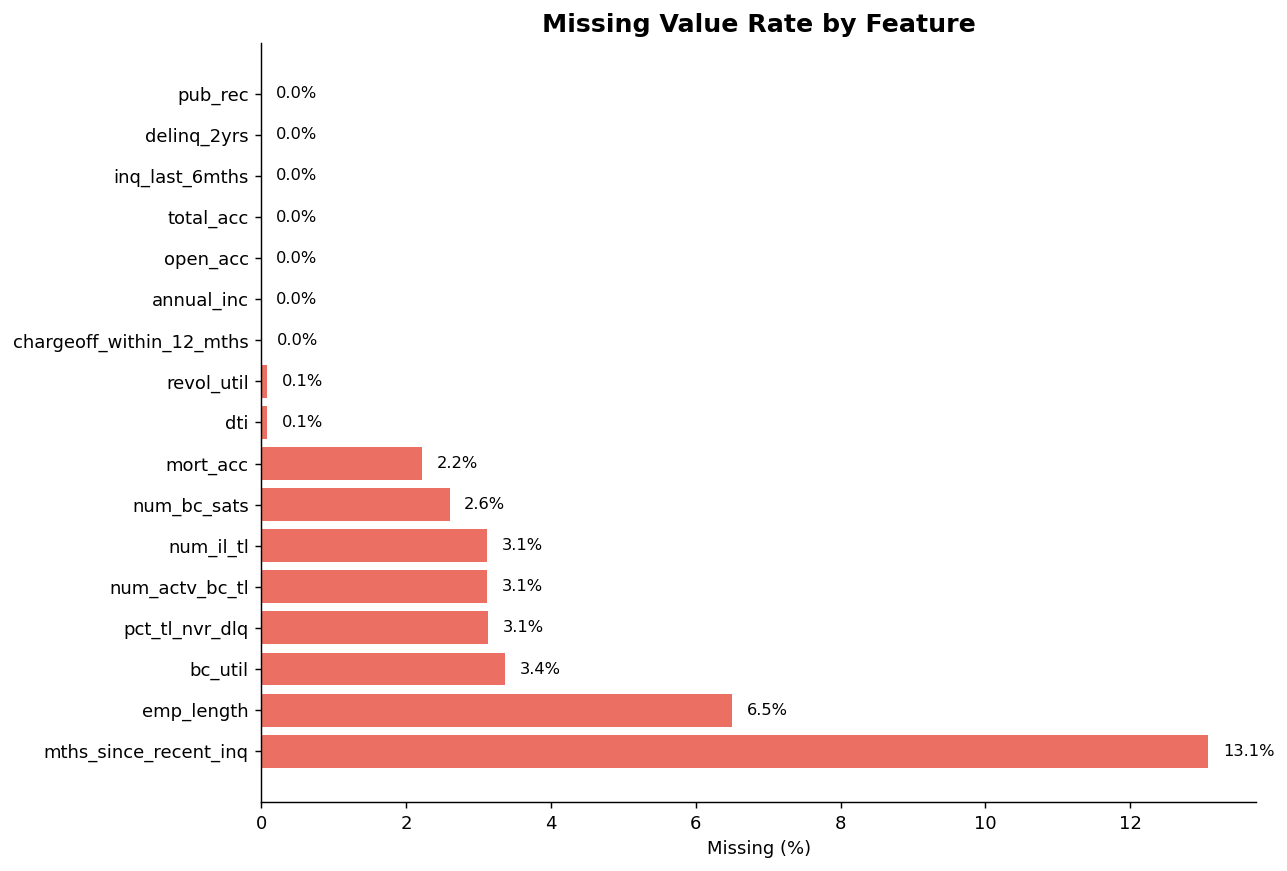

In [9]:
# ── Missing value visualisation ───────────────────────────────────────────────
if not missing_df.empty:
    fig, ax = plt.subplots(figsize=(10, max(4, len(missing_df) * 0.4)))
    bars = ax.barh(missing_df.index, missing_df['Missing %'], color='#E74C3C', alpha=0.8)
    ax.set_xlabel('Missing (%)')
    ax.set_title('Missing Value Rate by Feature')
    for bar, val in zip(bars, missing_df['Missing %']):
        ax.text(val + 0.2, bar.get_y() + bar.get_height()/2,
                f'{val:.1f}%', va='center', fontsize=9)
    plt.tight_layout()
    plt.savefig('plots/missing_values.png', bbox_inches='tight')
    plt.show()

In [10]:
import os
os.makedirs('plots', exist_ok=True)
os.makedirs('models', exist_ok=True)

In [11]:
# ── Clean: term ───────────────────────────────────────────────────────────────
if 'term' in df.columns:
    df['term'] = df['term'].astype(str).str.extract(r'(\d+)').astype(float)

# ── Clean: emp_length ─────────────────────────────────────────────────────────
if 'emp_length' in df.columns:
    df['emp_length'] = (
        df['emp_length']
        .astype(str)
        .str.replace('< 1 year', '0', regex=False)
        .str.replace('10+ years', '10', regex=False)
        .str.extract(r'(\d+)')
        .astype(float)
    )

# ── Clean: int_rate ────────────────────────────────────────────────────────────
if 'int_rate' in df.columns and df['int_rate'].dtype == object:
    df['int_rate'] = df['int_rate'].astype(str).str.replace('%', '').astype(float)

# ── Clean: revol_util ─────────────────────────────────────────────────────────
if 'revol_util' in df.columns and df['revol_util'].dtype == object:
    df['revol_util'] = df['revol_util'].astype(str).str.replace('%', '').astype(float)

print('Numeric cleaning complete.')
df.head(2)

Numeric cleaning complete.


,loan_amnt,term,int_rate,grade,sub_grade,annual_inc,emp_length,home_ownership,verification_status,purpose,addr_state,dti,delinq_2yrs,inq_last_6mths,revol_bal,revol_util,total_acc,open_acc,pub_rec,chargeoff_within_12_mths,mort_acc,num_actv_bc_tl,num_bc_sats,num_il_tl,mths_since_recent_inq,bc_util,pct_tl_nvr_dlq,installment,funded_amnt,funded_amnt_inv,target
0,2500,36.0000,13.5600,C,C1,55000.0000,10.0000,RENT,Not Verified,debt_consolidation,NY,18.2400,0.0000,1.0000,4341,10.3000,34.0000,9.0000,1.0000,0.0000,0.0000,2.0000,3.0000,16.0000,2.0000,5.9000,100.0000,84.9200,2500,2500.0000,0
1,30000,60.0000,18.9400,D,D2,90000.0000,10.0000,MORTGAGE,Source Verified,debt_consolidation,LA,26.5200,0.0000,0.0000,12315,24.2000,44.0000,13.0000,1.0000,0.0000,3.0000,2.0000,4.0000,27.0000,4.0000,8.3000,95.0000,777.2300,30000,30000.0000,0


In [12]:
# ── Encode categorical features ───────────────────────────────────────────────
CATEGORICAL_COLS = ['grade', 'sub_grade', 'home_ownership',
                    'verification_status', 'purpose', 'addr_state']
CATEGORICAL_COLS = [c for c in CATEGORICAL_COLS if c in df.columns]

le_dict = {}
for col in CATEGORICAL_COLS:
    le = LabelEncoder()
    df[col] = df[col].fillna('Unknown')
    df[col] = le.fit_transform(df[col].astype(str))
    le_dict[col] = le

print(f'Encoded {len(CATEGORICAL_COLS)} categorical columns.')

Encoded 6 categorical columns.


In [13]:
# ── Impute numeric missing values ─────────────────────────────────────────────
NUM_COLS = df.select_dtypes(include=[np.number]).columns.tolist()
NUM_COLS = [c for c in NUM_COLS if c != 'target']

# Use median imputation (robust to outliers)
for col in NUM_COLS:
    median_val = df[col].median()
    df[col] = df[col].fillna(median_val)

print(f'Imputed {len(NUM_COLS)} numeric columns with median.')
print(f'Remaining missing values: {df.isnull().sum().sum()}')

Imputed 30 numeric columns with median.


Remaining missing values: 0


In [14]:
# ── Outlier capping (Winsorization at 1st–99th percentile) ───────────────────
OUTLIER_COLS = ['annual_inc', 'revol_bal', 'loan_amnt', 'dti', 'installment']
OUTLIER_COLS = [c for c in OUTLIER_COLS if c in df.columns]

for col in OUTLIER_COLS:
    lo, hi = df[col].quantile([0.01, 0.99])
    df[col] = df[col].clip(lo, hi)

print('Outlier capping done.')

Outlier capping done.


---
## 4. Exploratory Data Analysis (EDA)
<a id='4-eda'></a>

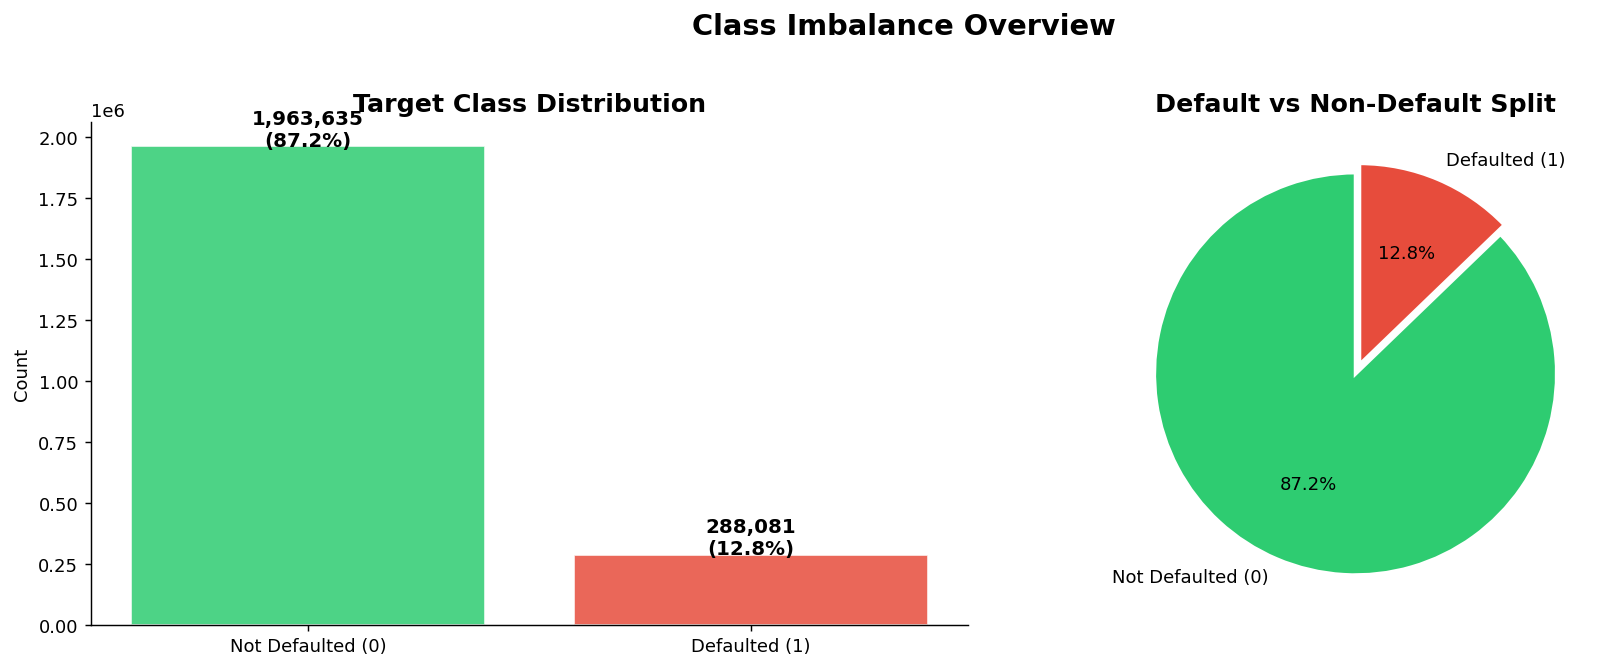

In [15]:
# ── 4.1 Target Class Distribution ─────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

counts = df['target'].value_counts()
labels = ['Not Defaulted (0)', 'Defaulted (1)']
colors = [PALETTE['paid'], PALETTE['default']]

# Bar chart
axes[0].bar(labels, counts.values, color=colors, alpha=0.85, edgecolor='white')
axes[0].set_title('Target Class Distribution')
axes[0].set_ylabel('Count')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 1000, f'{v:,}\n({v/len(df)*100:.1f}%)',
                 ha='center', fontsize=11, fontweight='bold')

# Pie chart
axes[1].pie(counts.values, labels=labels, colors=colors, autopct='%1.1f%%',
            startangle=90, explode=(0, 0.05),
            wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('Default vs Non-Default Split')

plt.suptitle('Class Imbalance Overview', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('plots/class_distribution.png', bbox_inches='tight')
plt.show()

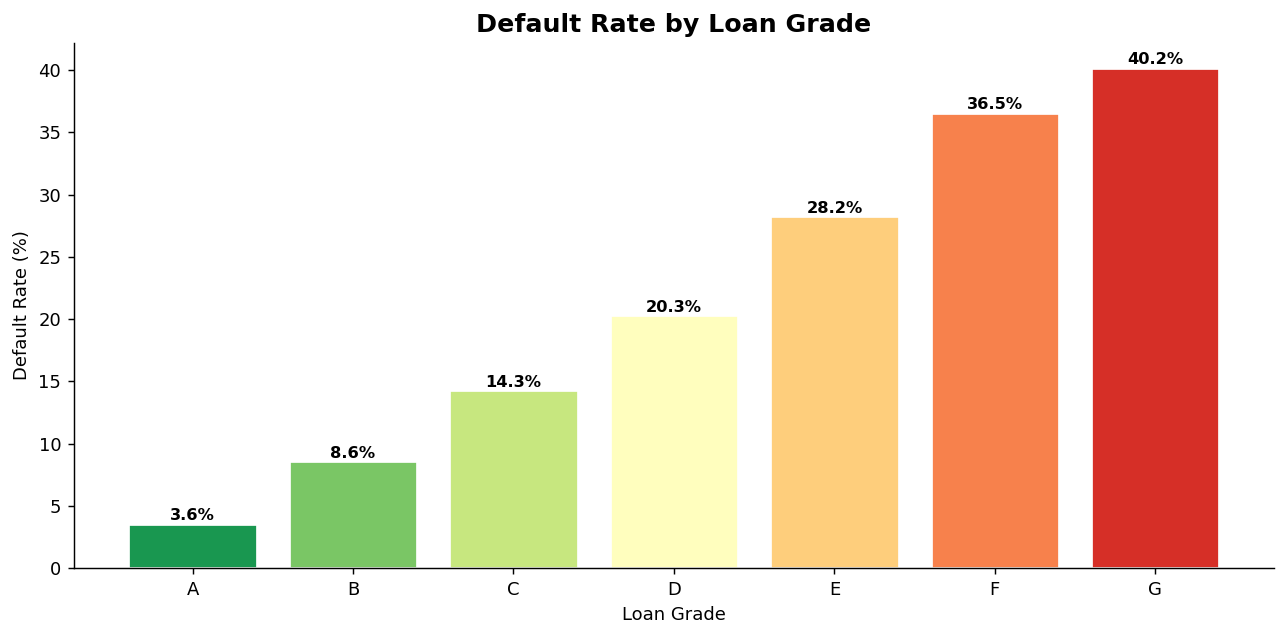

In [16]:
# ── 4.2 Default Rate by Grade ──────────────────────────────────────────────────
if 'grade' in df.columns:
    # Reverse map grade labels
    grade_labels = le_dict['grade'].classes_ if 'grade' in le_dict else None
    grade_dr = df.groupby('grade')['target'].mean().reset_index()
    grade_dr.columns = ['grade_code', 'default_rate']
    if grade_labels is not None:
        grade_dr['grade_label'] = grade_labels[grade_dr['grade_code']]
    else:
        grade_dr['grade_label'] = grade_dr['grade_code'].astype(str)
    grade_dr = grade_dr.sort_values('grade_label')

    fig, ax = plt.subplots(figsize=(10, 5))
    colors_g = plt.cm.RdYlGn_r(np.linspace(0.1, 0.9, len(grade_dr)))
    bars = ax.bar(grade_dr['grade_label'], grade_dr['default_rate'] * 100,
                  color=colors_g, edgecolor='white', linewidth=1.5)
    ax.set_xlabel('Loan Grade')
    ax.set_ylabel('Default Rate (%)')
    ax.set_title('Default Rate by Loan Grade')
    for bar, val in zip(bars, grade_dr['default_rate']):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                f'{val*100:.1f}%', ha='center', fontsize=9, fontweight='bold')
    plt.tight_layout()
    plt.savefig('plots/default_rate_by_grade.png', bbox_inches='tight')
    plt.show()

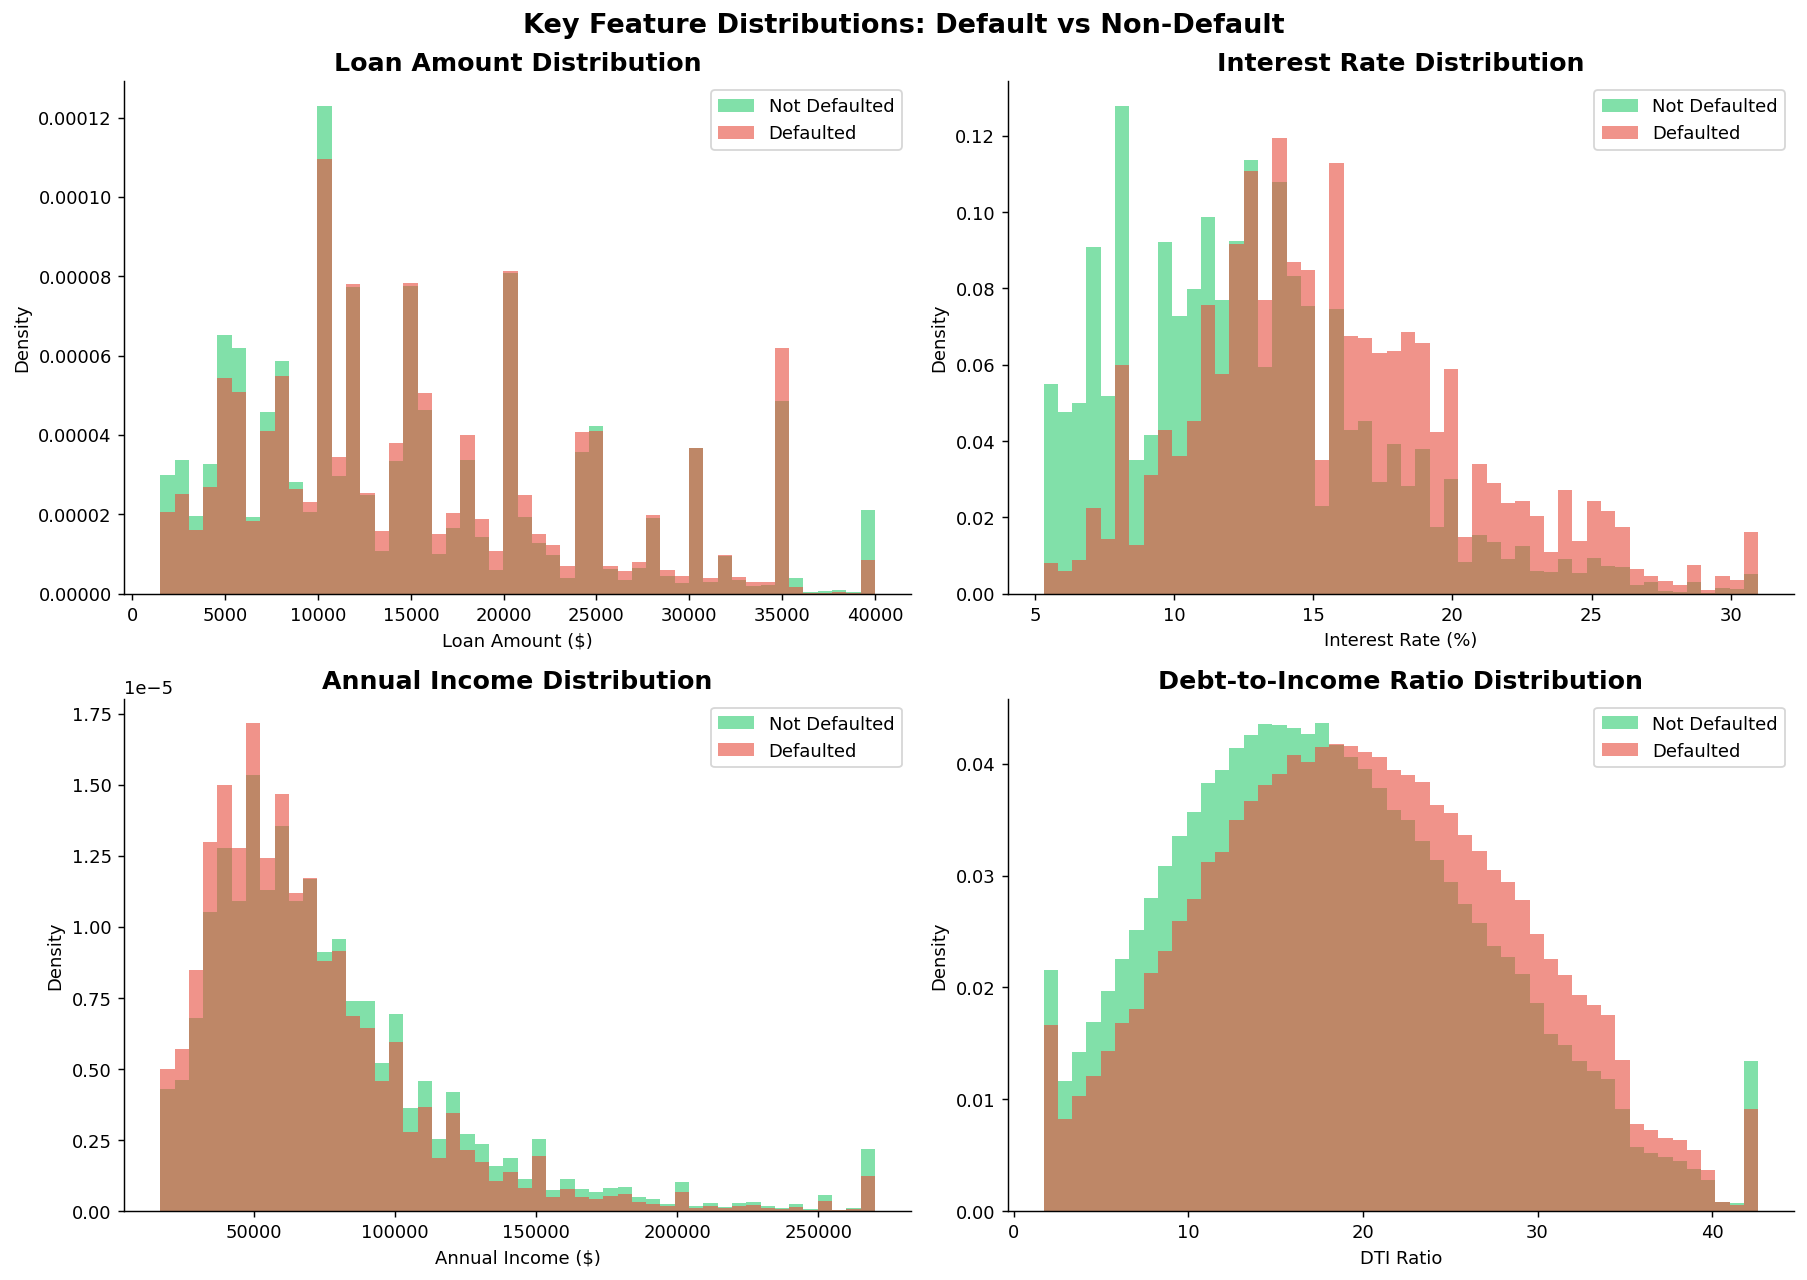

In [17]:
# ── 4.3 Loan Amount & Interest Rate Distributions ─────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

def plot_hist_by_target(ax, col, xlabel, title):
    if col not in df.columns:
        ax.set_visible(False)
        return
    for t, color, label in [(0, PALETTE['paid'], 'Not Defaulted'),
                             (1, PALETTE['default'], 'Defaulted')]:
        subset = df[df['target'] == t][col].dropna()
        ax.hist(subset, bins=50, alpha=0.6, color=color, label=label, density=True)
    ax.set_xlabel(xlabel)
    ax.set_ylabel('Density')
    ax.set_title(title)
    ax.legend()

plot_hist_by_target(axes[0, 0], 'loan_amnt', 'Loan Amount ($)', 'Loan Amount Distribution')
plot_hist_by_target(axes[0, 1], 'int_rate',  'Interest Rate (%)', 'Interest Rate Distribution')
plot_hist_by_target(axes[1, 0], 'annual_inc', 'Annual Income ($)', 'Annual Income Distribution')
plot_hist_by_target(axes[1, 1], 'dti',        'DTI Ratio', 'Debt-to-Income Ratio Distribution')

plt.suptitle('Key Feature Distributions: Default vs Non-Default', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('plots/feature_distributions.png', bbox_inches='tight')
plt.show()

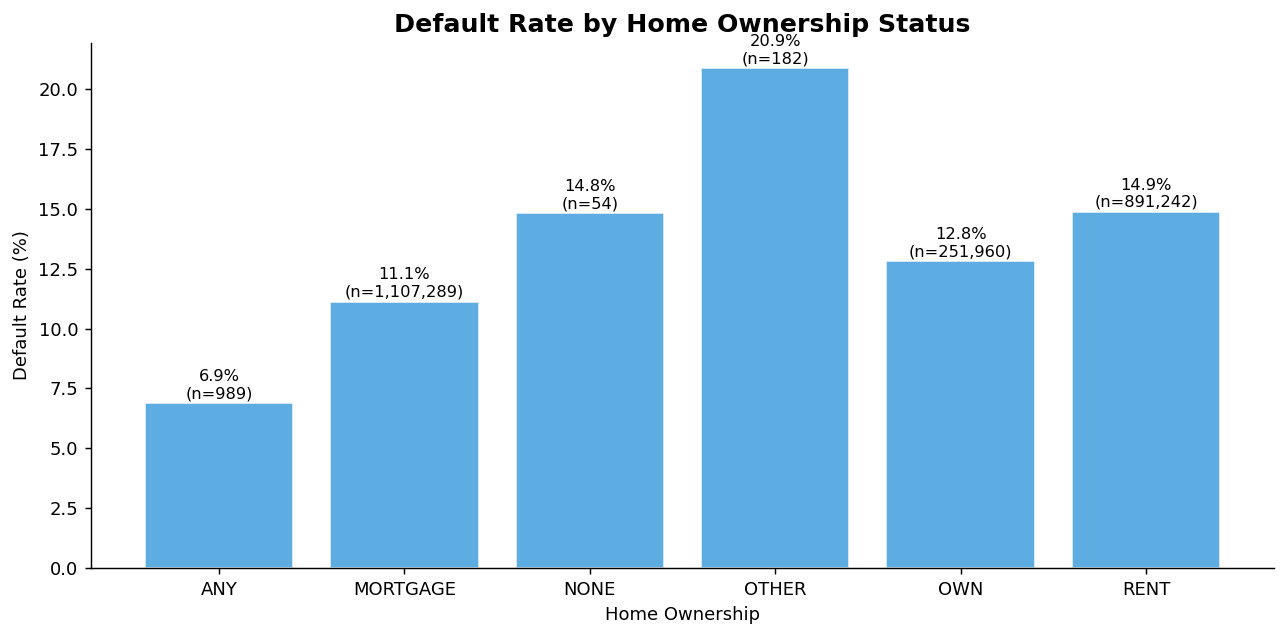

In [18]:
# ── 4.4 Default Rate by Home Ownership ────────────────────────────────────────
if 'home_ownership' in df.columns:
    own_labels = le_dict['home_ownership'].classes_ if 'home_ownership' in le_dict else None
    own_dr = df.groupby('home_ownership')['target'].agg(['mean', 'count']).reset_index()
    own_dr.columns = ['code', 'default_rate', 'count']
    if own_labels is not None:
        own_dr['label'] = own_labels[own_dr['code']]
    else:
        own_dr['label'] = own_dr['code'].astype(str)

    fig, ax = plt.subplots(figsize=(10, 5))
    bars = ax.bar(own_dr['label'], own_dr['default_rate'] * 100,
                  color=PALETTE['neutral'], alpha=0.8, edgecolor='white')
    ax.set_xlabel('Home Ownership')
    ax.set_ylabel('Default Rate (%)')
    ax.set_title('Default Rate by Home Ownership Status')
    for bar, val, cnt in zip(bars, own_dr['default_rate'], own_dr['count']):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
                f'{val*100:.1f}%\n(n={cnt:,})', ha='center', fontsize=9)
    plt.tight_layout()
    plt.savefig('plots/default_by_homeownership.png', bbox_inches='tight')
    plt.show()

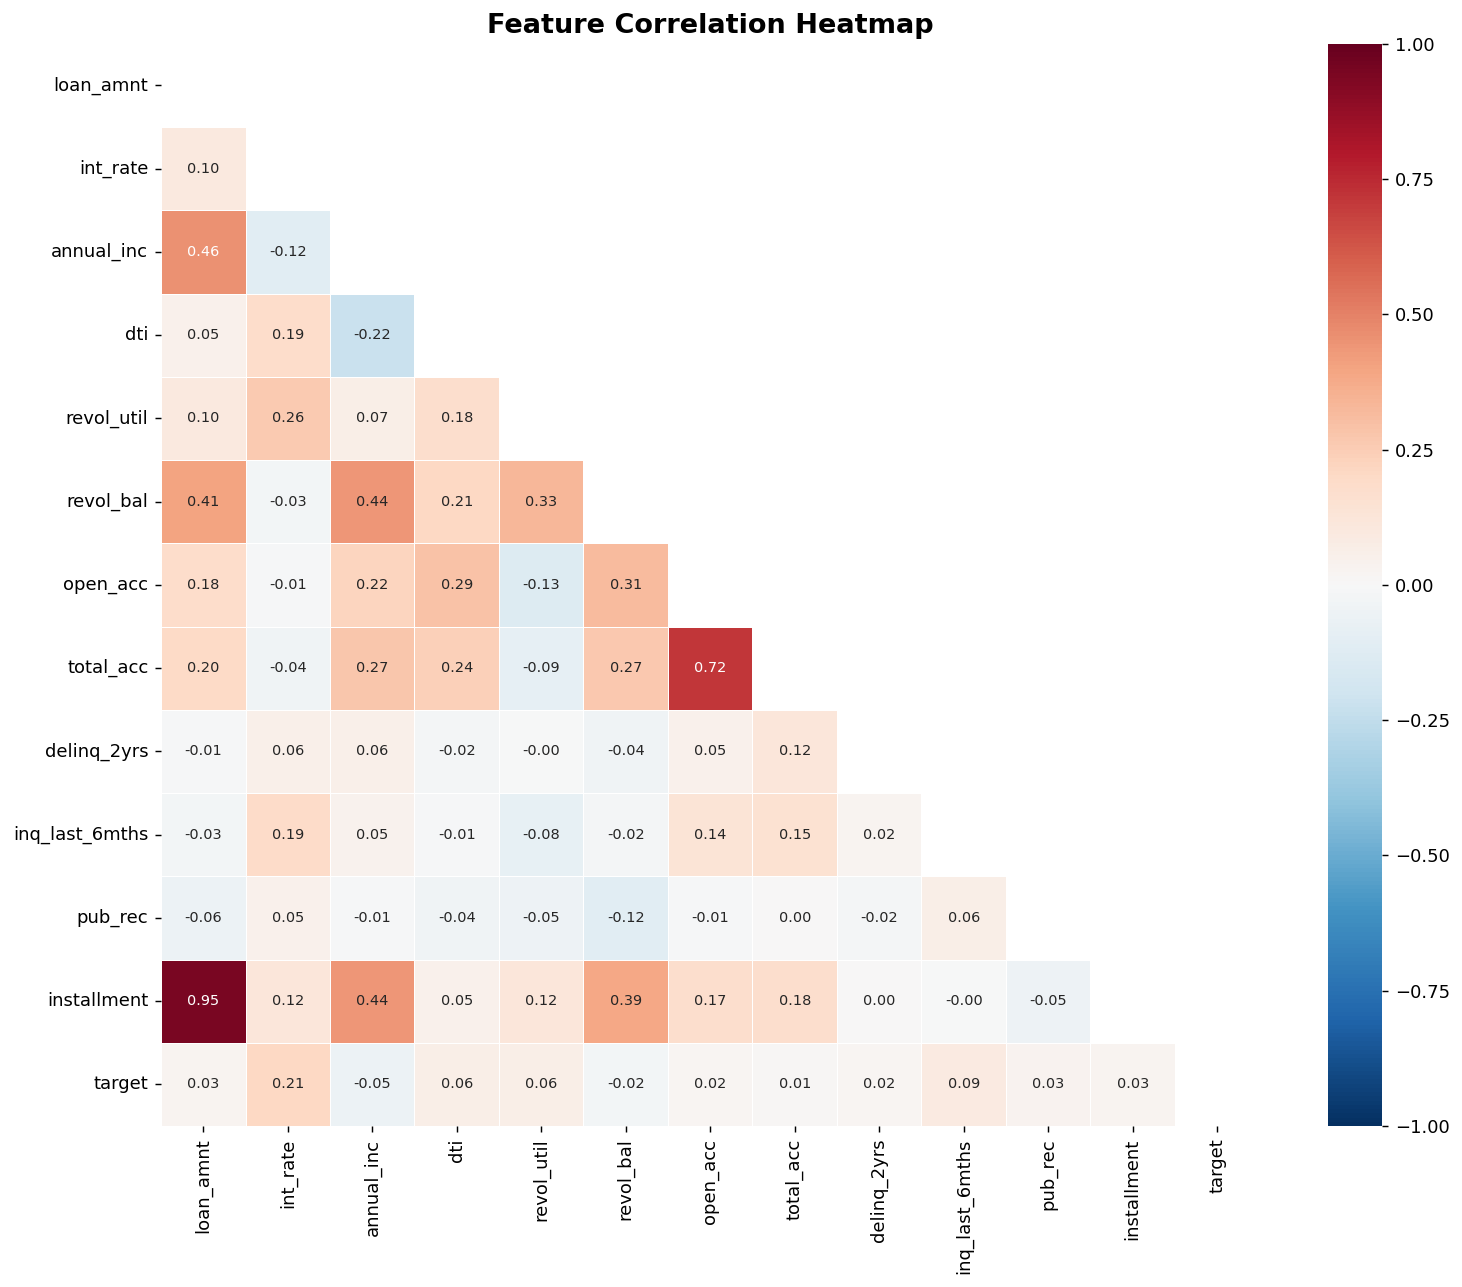

In [19]:
# ── 4.5 Correlation Heatmap ────────────────────────────────────────────────────
corr_cols = ['loan_amnt', 'int_rate', 'annual_inc', 'dti', 'revol_util',
             'revol_bal', 'open_acc', 'total_acc', 'delinq_2yrs',
             'inq_last_6mths', 'pub_rec', 'installment', 'target']
corr_cols = [c for c in corr_cols if c in df.columns]

corr_matrix = df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(12, 10))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f',
            cmap='RdBu_r', center=0, vmin=-1, vmax=1,
            linewidths=0.5, ax=ax, annot_kws={'size': 8})
ax.set_title('Feature Correlation Heatmap', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('plots/correlation_heatmap.png', bbox_inches='tight')
plt.show()

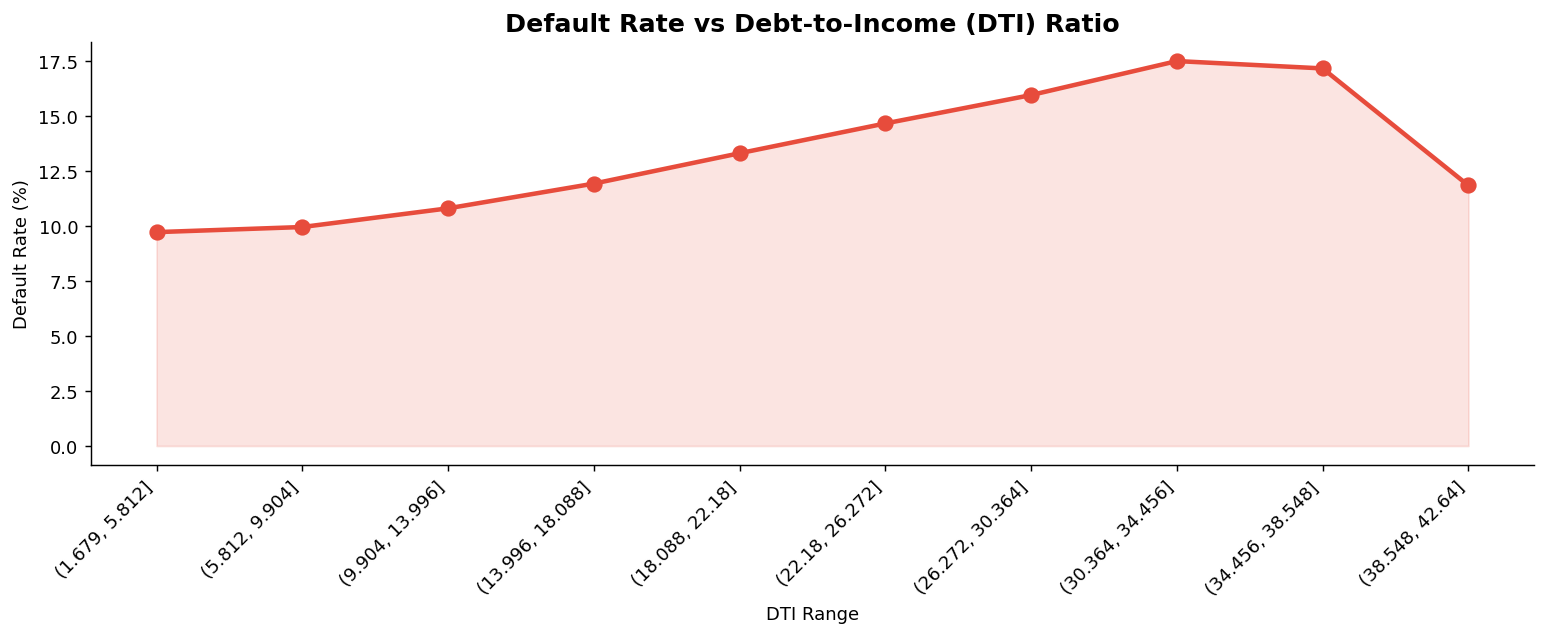

In [20]:
# ── 4.6 Default Rate vs DTI (binned) ──────────────────────────────────────────
if 'dti' in df.columns:
    df['dti_bin'] = pd.cut(df['dti'], bins=10)
    dti_dr = df.groupby('dti_bin')['target'].mean().reset_index()

    fig, ax = plt.subplots(figsize=(12, 5))
    ax.plot(range(len(dti_dr)), dti_dr['target'] * 100, marker='o',
            color=PALETTE['default'], linewidth=2.5, markersize=8)
    ax.fill_between(range(len(dti_dr)), dti_dr['target'] * 100,
                    alpha=0.15, color=PALETTE['default'])
    ax.set_xticks(range(len(dti_dr)))
    ax.set_xticklabels([str(b) for b in dti_dr['dti_bin']], rotation=45, ha='right')
    ax.set_xlabel('DTI Range')
    ax.set_ylabel('Default Rate (%)')
    ax.set_title('Default Rate vs Debt-to-Income (DTI) Ratio')
    plt.tight_layout()
    plt.savefig('plots/default_vs_dti.png', bbox_inches='tight')
    plt.show()
    df.drop(columns=['dti_bin'], inplace=True)

---
## 5. Feature Engineering
<a id='5-feature-engineering'></a>

In [21]:
# ── Derived features ─────────────────────────────────────────────────────────
# 1. Income-to-Loan Ratio: how much annual income covers the loan
if 'annual_inc' in df.columns and 'loan_amnt' in df.columns:
    df['income_to_loan_ratio'] = df['annual_inc'] / (df['loan_amnt'] + 1)

# 2. Interest Burden: monthly installment as % of monthly income
if 'installment' in df.columns and 'annual_inc' in df.columns:
    df['interest_burden'] = (df['installment'] * 12) / (df['annual_inc'] + 1)

# 3. Loan-to-Income Ratio (inverse of income_to_loan for different scaling)
if 'loan_amnt' in df.columns and 'annual_inc' in df.columns:
    df['loan_to_income'] = df['loan_amnt'] / (df['annual_inc'] + 1)

# 4. Open-to-Total Account Ratio (credit utilization breadth)
if 'open_acc' in df.columns and 'total_acc' in df.columns:
    df['open_acc_ratio'] = df['open_acc'] / (df['total_acc'] + 1)

# 5. Total Delinquency Score
delin_cols = [c for c in ['delinq_2yrs', 'pub_rec', 'chargeoff_within_12_mths'] if c in df.columns]
if delin_cols:
    df['total_delinquency'] = df[delin_cols].sum(axis=1)

# 6. High interest flag
if 'int_rate' in df.columns:
    df['high_interest'] = (df['int_rate'] > df['int_rate'].quantile(0.75)).astype(int)

print('✅ Feature engineering complete.')
print(f'Total features (excl. target): {len([c for c in df.columns if c != "target"])}')
df[['income_to_loan_ratio', 'interest_burden', 'loan_to_income',
    'open_acc_ratio', 'total_delinquency', 'high_interest']].describe()

✅ Feature engineering complete.
Total features (excl. target): 36


,income_to_loan_ratio,interest_burden,loan_to_income,open_acc_ratio,total_delinquency,high_interest
count,2251716.0000,2251716.0000,2251716.0000,2251716.0000,2251716.0000,2251716.0000
mean,6.9979,0.0806,0.2241,0.4911,0.5124,0.2436
std,6.7621,0.0513,0.1447,0.1624,1.0444,0.4292
min,0.4200,0.0024,0.0056,0.0000,0.0000,0.0000
25%,3.3597,0.0460,0.1250,0.3721,0.0000,0.0000
50%,4.9996,0.0714,0.2000,0.4783,0.0000,0.0000
75%,7.9984,0.1050,0.2976,0.6000,1.0000,0.0000
max,179.8801,0.8837,2.3808,1.5556,86.0000,1.0000


---
## 6. Model Building & Training
<a id='6-modeling'></a>

In [22]:
# ── Train/Test Split ──────────────────────────────────────────────────────────
FEATURE_COLS = [c for c in df.columns if c != 'target']
X = df[FEATURE_COLS].copy()
y = df['target'].copy()

# Stratified split to preserve class ratio
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print(f'Training set  : {X_train.shape[0]:,} rows')
print(f'Test set      : {X_test.shape[0]:,} rows')
print(f'\nTrain default rate: {y_train.mean():.4f}')
print(f'Test  default rate: {y_test.mean():.4f}')

Training set  : 1,801,372 rows
Test set      : 450,344 rows

Train default rate: 0.1279
Test  default rate: 0.1279


In [23]:
# ── Feature Scaling ────────────────────────────────────────────────────────────
scaler = RobustScaler()  # Robust to outliers
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

joblib.dump(scaler, 'models/scaler.pkl')
print('Scaler saved.')

Scaler saved.


In [24]:
# ── Helper: evaluate model ─────────────────────────────────────────────────────
def evaluate_model(name, model, X_test_data, y_test_data, use_proba=True):
    """Compute and return a dict of evaluation metrics."""
    y_pred = model.predict(X_test_data)
    if use_proba:
        y_proba = model.predict_proba(X_test_data)[:, 1]
    else:
        y_proba = model.decision_function(X_test_data)

    metrics = {
        'Model'      : name,
        'Accuracy'   : accuracy_score(y_test_data, y_pred),
        'Precision'  : precision_score(y_test_data, y_pred, zero_division=0),
        'Recall'     : recall_score(y_test_data, y_pred, zero_division=0),
        'F1-Score'   : f1_score(y_test_data, y_pred, zero_division=0),
        'ROC-AUC'    : roc_auc_score(y_test_data, y_proba),
        'y_proba'    : y_proba,
        'y_pred'     : y_pred,
    }
    return metrics

all_results = []
print('Evaluation helper defined.')

Evaluation helper defined.


In [25]:
# ── Model 1: Logistic Regression ──────────────────────────────────────────────
print('Training Logistic Regression ...')
lr_model = LogisticRegression(
    max_iter=1000, random_state=42,
    class_weight='balanced', solver='saga', n_jobs=-1
)
lr_model.fit(X_train_scaled, y_train)
lr_results = evaluate_model('Logistic Regression', lr_model, X_test_scaled, y_test)
all_results.append(lr_results)
joblib.dump(lr_model, 'models/logistic_regression.pkl')

print(f"  Accuracy : {lr_results['Accuracy']:.4f}")
print(f"  ROC-AUC  : {lr_results['ROC-AUC']:.4f}")
print(f"  F1-Score : {lr_results['F1-Score']:.4f}")

Training Logistic Regression ...


  Accuracy : 0.6610
  ROC-AUC  : 0.7185
  F1-Score : 0.3316


In [26]:
# ── Model 2: Decision Tree ────────────────────────────────────────────────────
print('Training Decision Tree ...')
dt_model = DecisionTreeClassifier(
    max_depth=8, min_samples_split=200, min_samples_leaf=100,
    class_weight='balanced', random_state=42
)
dt_model.fit(X_train, y_train)
dt_results = evaluate_model('Decision Tree', dt_model, X_test, y_test)
all_results.append(dt_results)
joblib.dump(dt_model, 'models/decision_tree.pkl')

print(f"  Accuracy : {dt_results['Accuracy']:.4f}")
print(f"  ROC-AUC  : {dt_results['ROC-AUC']:.4f}")
print(f"  F1-Score : {dt_results['F1-Score']:.4f}")

Training Decision Tree ...


  Accuracy : 0.6464
  ROC-AUC  : 0.7236
  F1-Score : 0.3310


In [27]:
# ── Model 3: Random Forest ─────────────────────────────────────────────────────
print('Training Random Forest (this may take a few minutes) ...')
rf_model = RandomForestClassifier(
    n_estimators=200, max_depth=12,
    min_samples_split=100, min_samples_leaf=50,
    class_weight='balanced', random_state=42, n_jobs=-1
)
rf_model.fit(X_train, y_train)
rf_results = evaluate_model('Random Forest', rf_model, X_test, y_test)
all_results.append(rf_results)
joblib.dump(rf_model, 'models/random_forest.pkl')

print(f"  Accuracy : {rf_results['Accuracy']:.4f}")
print(f"  ROC-AUC  : {rf_results['ROC-AUC']:.4f}")
print(f"  F1-Score : {rf_results['F1-Score']:.4f}")

Training Random Forest (this may take a few minutes) ...


  Accuracy : 0.6558
  ROC-AUC  : 0.7242
  F1-Score : 0.3326


In [28]:
# ── Model 4: XGBoost (if available) ───────────────────────────────────────────
if XGB_AVAILABLE:
    print('Training XGBoost ...')
    scale_pos = (y_train == 0).sum() / (y_train == 1).sum()
    xgb_model = xgb.XGBClassifier(
        n_estimators=300, max_depth=6, learning_rate=0.1,
        subsample=0.8, colsample_bytree=0.8,
        scale_pos_weight=scale_pos,
        use_label_encoder=False, eval_metric='auc',
        random_state=42, n_jobs=-1, verbosity=0
    )
    xgb_model.fit(X_train, y_train,
                  eval_set=[(X_test, y_test)],
                  verbose=False)
    xgb_results = evaluate_model('XGBoost', xgb_model, X_test, y_test)
    all_results.append(xgb_results)
    joblib.dump(xgb_model, 'models/xgboost.pkl')
    print(f"  Accuracy : {xgb_results['Accuracy']:.4f}")
    print(f"  ROC-AUC  : {xgb_results['ROC-AUC']:.4f}")
    print(f"  F1-Score : {xgb_results['F1-Score']:.4f}")
else:
    print('XGBoost not available – skipped.')

Training XGBoost ...


  Accuracy : 0.6646
  ROC-AUC  : 0.7521
  F1-Score : 0.3520


In [29]:
# ── Model 5: LightGBM (if available) ──────────────────────────────────────────
if LGB_AVAILABLE:
    print('Training LightGBM ...')
    scale_pos = (y_train == 0).sum() / (y_train == 1).sum()
    lgb_model = lgb.LGBMClassifier(
        n_estimators=300, max_depth=6, learning_rate=0.1,
        subsample=0.8, colsample_bytree=0.8,
        scale_pos_weight=scale_pos,
        random_state=42, n_jobs=-1, verbose=-1
    )
    lgb_model.fit(X_train, y_train,
                  eval_set=[(X_test, y_test)],
                  callbacks=[lgb.early_stopping(50, verbose=False),
                              lgb.log_evaluation(period=-1)])
    lgb_results = evaluate_model('LightGBM', lgb_model, X_test, y_test)
    all_results.append(lgb_results)
    joblib.dump(lgb_model, 'models/lightgbm.pkl')
    print(f"  Accuracy : {lgb_results['Accuracy']:.4f}")
    print(f"  ROC-AUC  : {lgb_results['ROC-AUC']:.4f}")
    print(f"  F1-Score : {lgb_results['F1-Score']:.4f}")
else:
    print('LightGBM not available – skipped.')

Training LightGBM ...


  Accuracy : 0.8721
  ROC-AUC  : 0.7064
  F1-Score : 0.0000


---
## 7. Model Evaluation
<a id='7-evaluation'></a>

In [30]:
# ── 7.1 Comparative Metrics Table ─────────────────────────────────────────────
metrics_df = pd.DataFrame([{
    'Model'    : r['Model'],
    'Accuracy' : round(r['Accuracy'], 4),
    'Precision': round(r['Precision'], 4),
    'Recall'   : round(r['Recall'], 4),
    'F1-Score' : round(r['F1-Score'], 4),
    'ROC-AUC'  : round(r['ROC-AUC'], 4),
} for r in all_results])

print('=== Model Comparison ===')
print(metrics_df.to_string(index=False))

=== Model Comparison ===
              Model  Accuracy  Precision  Recall  F1-Score  ROC-AUC
Logistic Regression    0.6610     0.2217  0.6573    0.3316   0.7185
      Decision Tree    0.6464     0.2184  0.6839    0.3310   0.7236
      Random Forest    0.6558     0.2212  0.6705    0.3326   0.7242
            XGBoost    0.6646     0.2338  0.7119    0.3520   0.7521
           LightGBM    0.8721     0.0000  0.0000    0.0000   0.7064


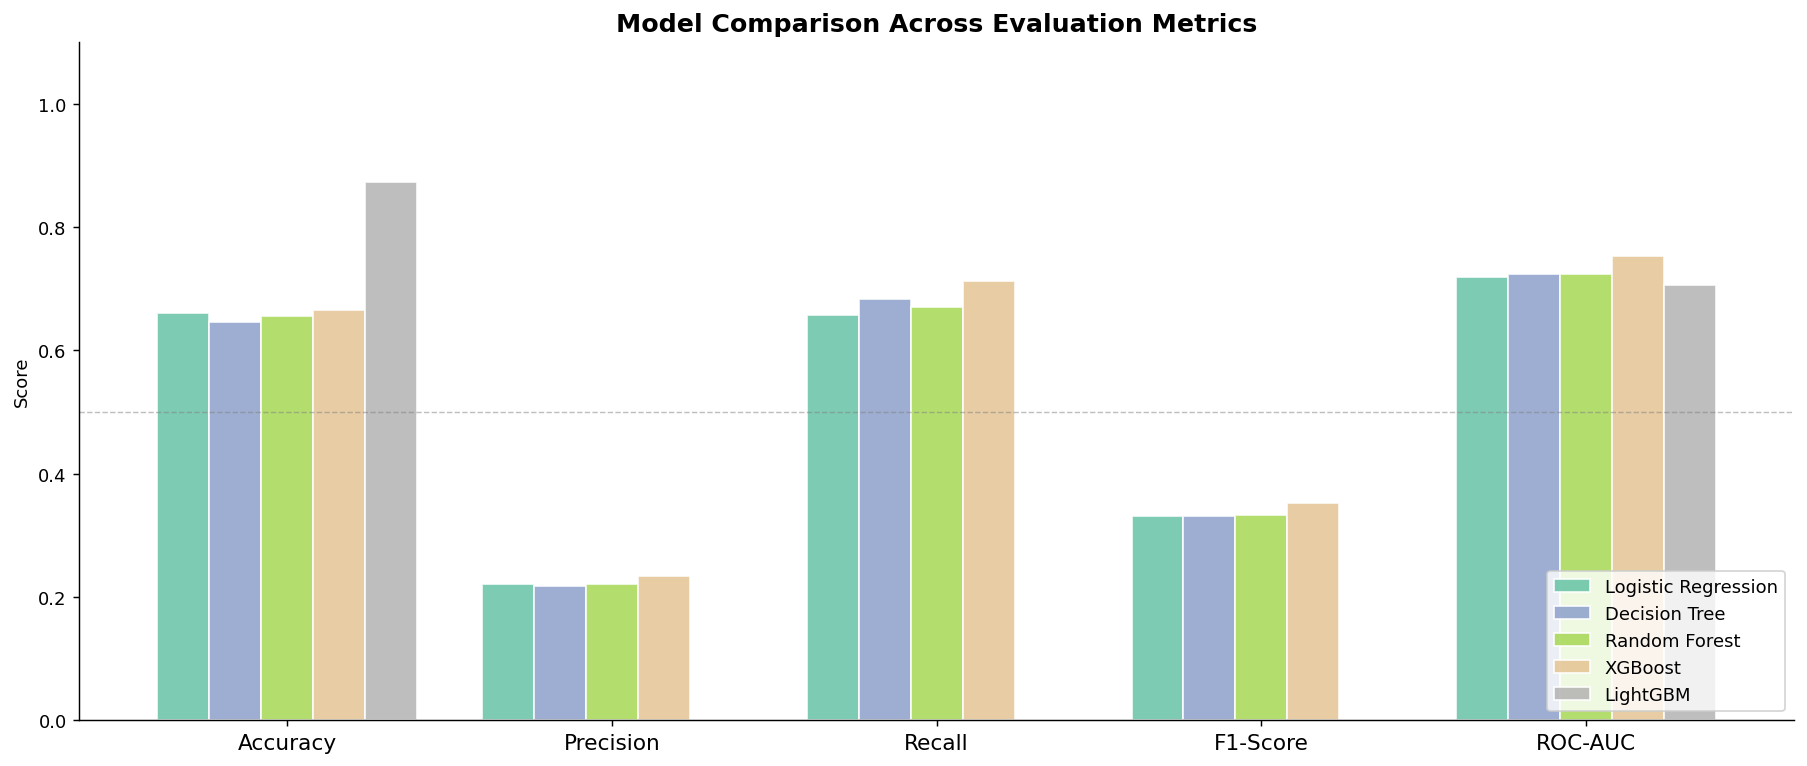

In [31]:
# ── 7.2 Metrics Bar Chart ──────────────────────────────────────────────────────
metric_names = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']
x = np.arange(len(metric_names))
width = 0.8 / len(all_results)

fig, ax = plt.subplots(figsize=(14, 6))
colors_m = plt.cm.Set2(np.linspace(0, 1, len(all_results)))

for i, (result, color) in enumerate(zip(all_results, colors_m)):
    vals = [result[m] for m in metric_names]
    offset = (i - len(all_results)/2 + 0.5) * width
    bars = ax.bar(x + offset, vals, width, label=result['Model'],
                  color=color, alpha=0.85, edgecolor='white')

ax.set_xticks(x)
ax.set_xticklabels(metric_names, fontsize=12)
ax.set_ylim(0, 1.1)
ax.set_ylabel('Score')
ax.set_title('Model Comparison Across Evaluation Metrics', fontsize=14)
ax.legend(loc='lower right', fontsize=10)
ax.axhline(0.5, color='gray', linestyle='--', linewidth=0.8, alpha=0.5)
plt.tight_layout()
plt.savefig('plots/model_comparison.png', bbox_inches='tight')
plt.show()

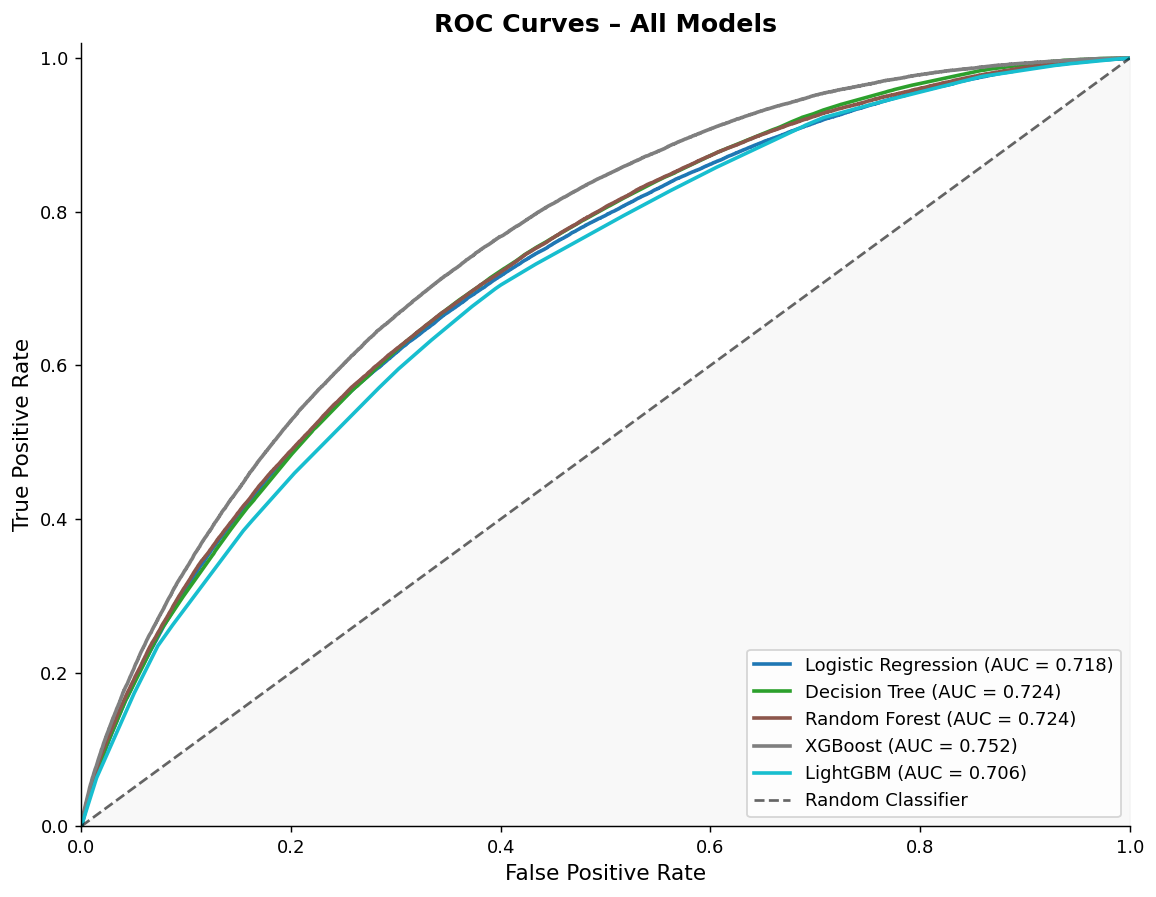

In [32]:
# ── 7.3 ROC Curves ────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 7))
colors_roc = plt.cm.tab10(np.linspace(0, 1, len(all_results)))

for result, color in zip(all_results, colors_roc):
    fpr, tpr, _ = roc_curve(y_test, result['y_proba'])
    auc_val = result['ROC-AUC']
    ax.plot(fpr, tpr, color=color, lw=2,
            label=f"{result['Model']} (AUC = {auc_val:.3f})")

ax.plot([0, 1], [0, 1], 'k--', lw=1.5, alpha=0.6, label='Random Classifier')
ax.fill_between([0, 1], [0, 1], alpha=0.05, color='gray')
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('ROC Curves – All Models', fontsize=14)
ax.legend(loc='lower right', fontsize=10)
ax.set_xlim([0, 1])
ax.set_ylim([0, 1.02])
plt.tight_layout()
plt.savefig('plots/roc_curves.png', bbox_inches='tight')
plt.show()


🏆 Best model: XGBoost (ROC-AUC = 0.7521)


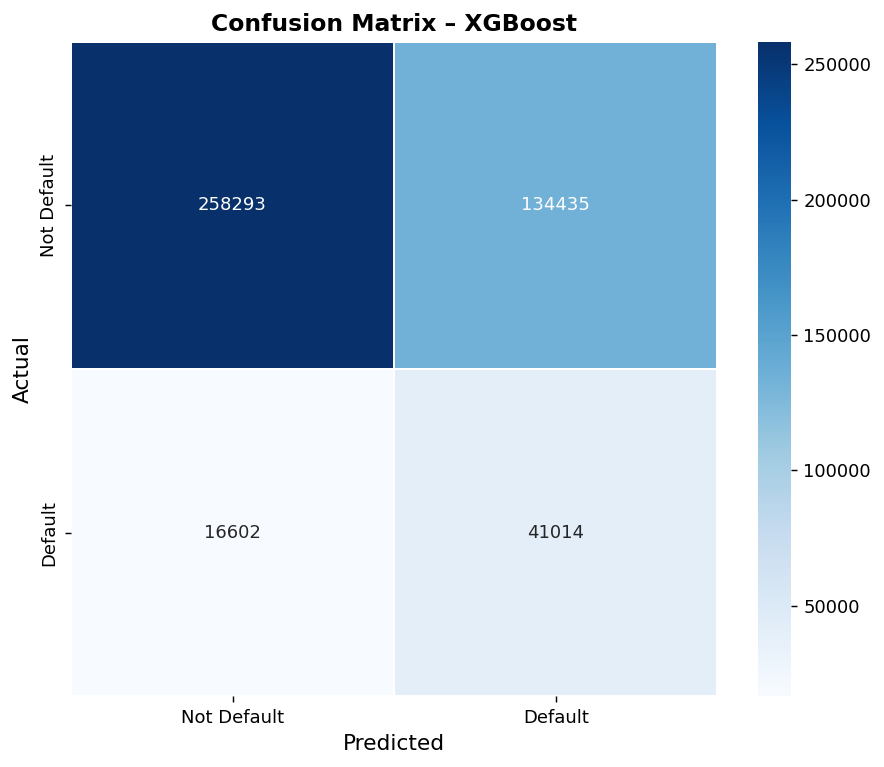


Classification Report:


              precision    recall  f1-score   support

 Not Default       0.94      0.66      0.77    392728
     Default       0.23      0.71      0.35     57616

    accuracy                           0.66    450344
   macro avg       0.59      0.68      0.56    450344
weighted avg       0.85      0.66      0.72    450344



In [33]:
# ── 7.4 Best Model: Confusion Matrix ──────────────────────────────────────────
best_result = max(all_results, key=lambda r: r['ROC-AUC'])
print(f"\n🏆 Best model: {best_result['Model']} (ROC-AUC = {best_result['ROC-AUC']:.4f})")

cm = confusion_matrix(y_test, best_result['y_pred'])
fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=['Not Default', 'Default'],
            yticklabels=['Not Default', 'Default'],
            linewidths=1, linecolor='white')
ax.set_xlabel('Predicted', fontsize=12)
ax.set_ylabel('Actual', fontsize=12)
ax.set_title(f'Confusion Matrix – {best_result["Model"]}', fontsize=13)
plt.tight_layout()
plt.savefig('plots/confusion_matrix_best.png', bbox_inches='tight')
plt.show()

print('\nClassification Report:')
print(classification_report(y_test, best_result['y_pred'],
                            target_names=['Not Default', 'Default']))

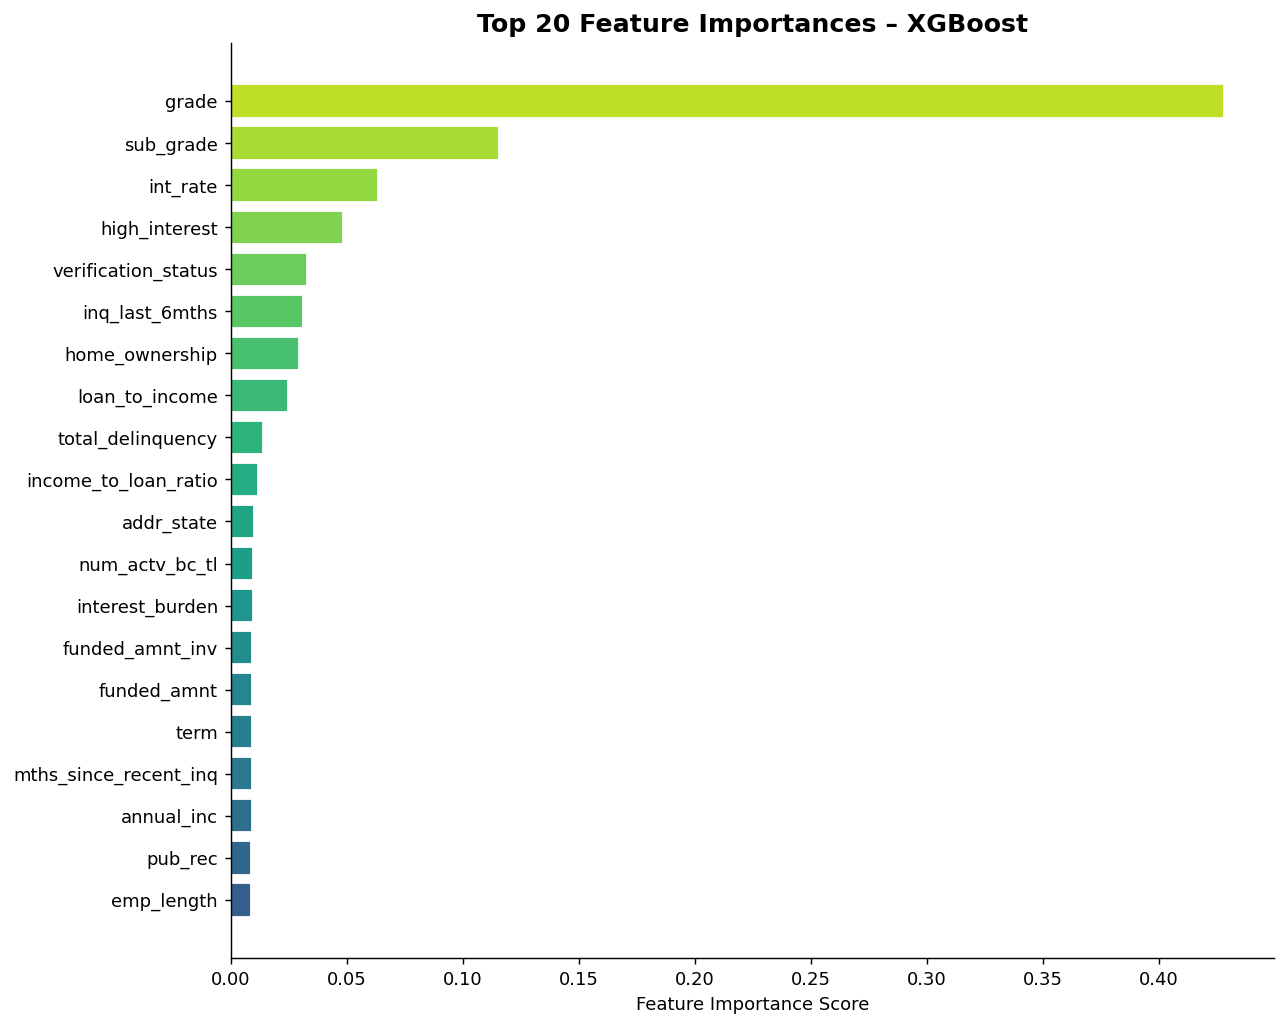

In [34]:
# ── 7.5 Feature Importance (Best Model) ──────────────────────────────────────
# Choose the best tree-based model for feature importance
tree_results = [(r, m) for r, m in [
    (rf_results, rf_model),
    (xgb_results, xgb_model) if XGB_AVAILABLE else (None, None),
    (lgb_results, lgb_model) if LGB_AVAILABLE else (None, None),
] if r is not None and r['ROC-AUC'] == best_result['ROC-AUC']]

# Use best tree model for importance
best_tree_result = max(
    [(r, m) for r, m in [
        (rf_results, rf_model),
        (xgb_results if XGB_AVAILABLE else None, xgb_model if XGB_AVAILABLE else None),
        (lgb_results if LGB_AVAILABLE else None, lgb_model if LGB_AVAILABLE else None),
    ] if r is not None],
    key=lambda x: x[0]['ROC-AUC']
)
best_tree_r, best_tree_m = best_tree_result

if hasattr(best_tree_m, 'feature_importances_'):
    importances = pd.Series(best_tree_m.feature_importances_, index=FEATURE_COLS)
    importances = importances.sort_values(ascending=True).tail(20)

    fig, ax = plt.subplots(figsize=(10, 8))
    colors_fi = plt.cm.viridis(np.linspace(0.3, 0.9, len(importances)))
    ax.barh(importances.index, importances.values, color=colors_fi, edgecolor='white')
    ax.set_xlabel('Feature Importance Score')
    ax.set_title(f'Top 20 Feature Importances – {best_tree_r["Model"]}')
    plt.tight_layout()
    plt.savefig('plots/feature_importance.png', bbox_inches='tight')
    plt.show()

---
## 8. Risk Bucketing & Tiering
<a id='8-risk-bucketing'></a>

In [35]:
# ── Get best model probabilities ──────────────────────────────────────────────
best_model_name = best_result['Model']
best_proba = best_result['y_proba']

# Use the full dataset for portfolio-level work
# (Re-predict on combined for completeness)
df_results = X_test.copy()
df_results['target'] = y_test.values
df_results['default_prob'] = best_proba

# ── Risk Bucketing ─────────────────────────────────────────────────────────────
def assign_risk_tier(prob):
    if prob < 0.30:
        return 'Low Risk'
    elif prob < 0.55:
        return 'Medium Risk'
    else:
        return 'High Risk'

df_results['risk_tier'] = df_results['default_prob'].apply(assign_risk_tier)

# ── Lending Action Recommendation ─────────────────────────────────────────────
ACTION_MAP = {
    'Low Risk'   : 'Approve',
    'Medium Risk': 'Review',
    'High Risk'  : 'Reject',
}
RATE_RANGE_MAP = {
    'Low Risk'   : '5% – 10%',
    'Medium Risk': '11% – 17%',
    'High Risk'  : '18% – 24%+',
}

df_results['lending_action'] = df_results['risk_tier'].map(ACTION_MAP)
df_results['suggested_rate'] = df_results['risk_tier'].map(RATE_RANGE_MAP)

print('=== Risk Tier Distribution ===')
print(df_results['risk_tier'].value_counts())
print('\n=== Actual Default Rate per Tier ===')
print(df_results.groupby('risk_tier')['target'].mean().round(4))

=== Risk Tier Distribution ===
risk_tier
Medium Risk    168541
Low Risk       141311
High Risk      140492
Name: count, dtype: int64

=== Actual Default Rate per Tier ===
risk_tier
High Risk     0.2556
Low Risk      0.0277
Medium Risk   0.1055
Name: target, dtype: float64


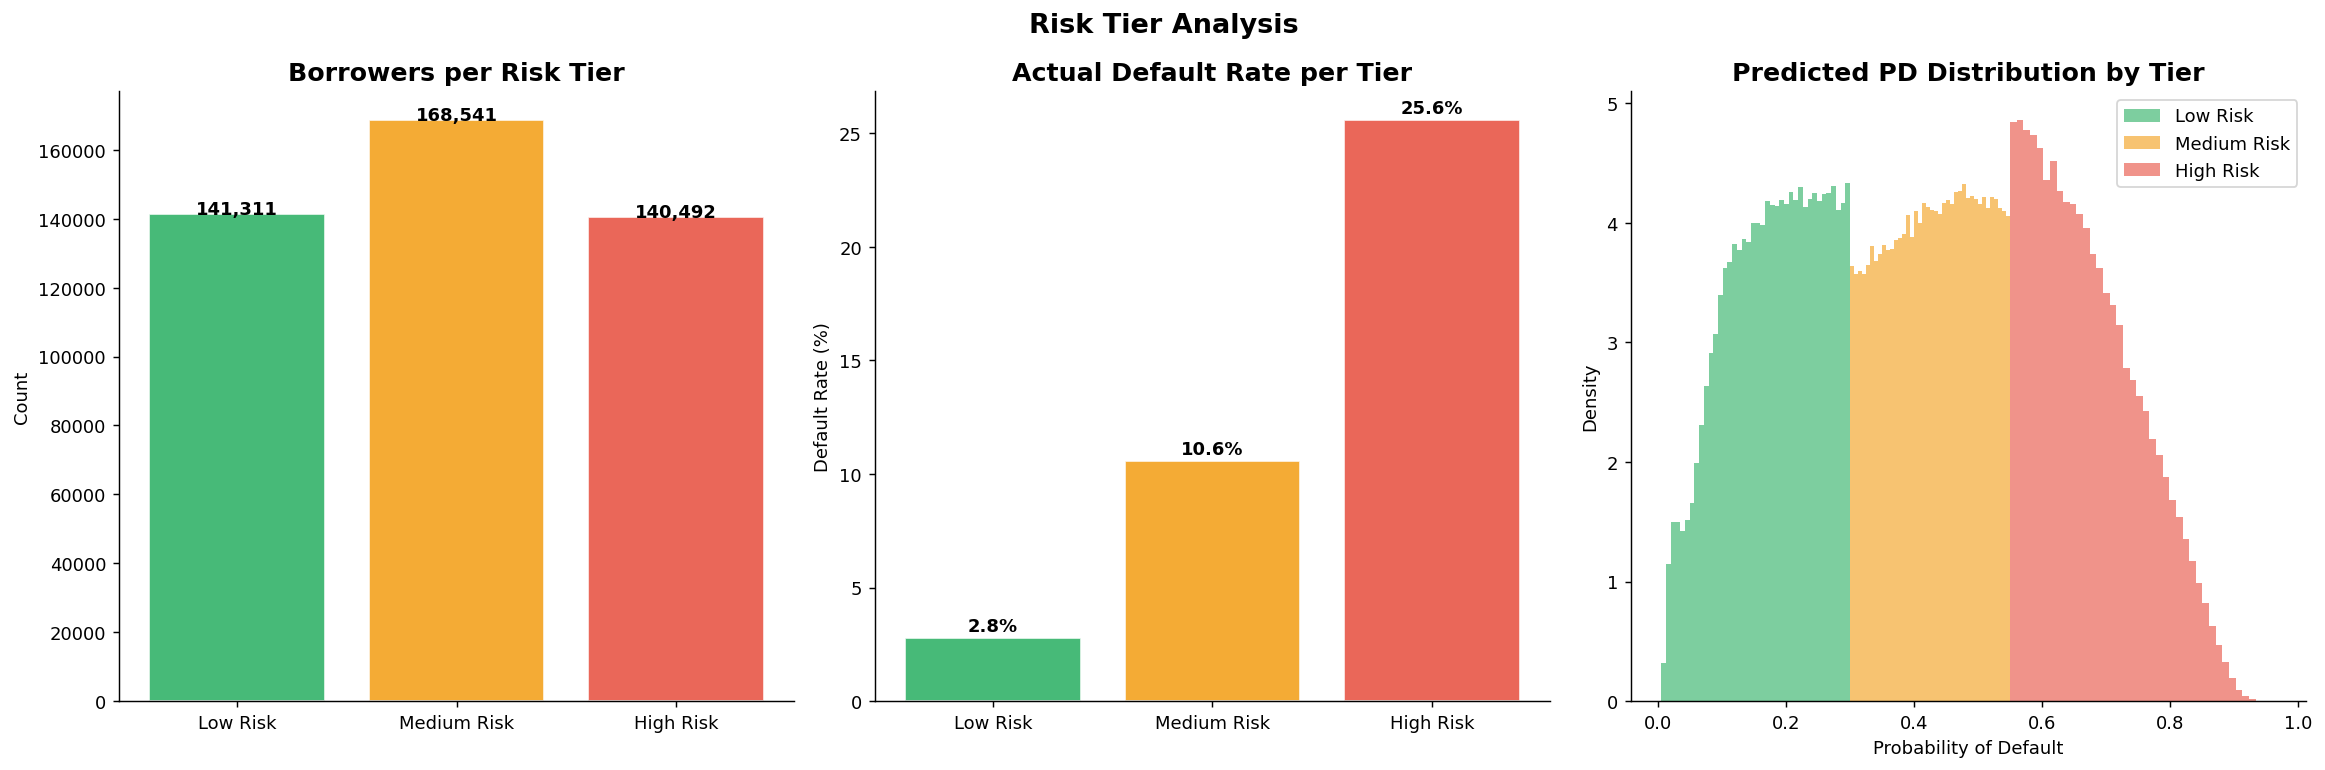

In [36]:
# ── 8.1 Risk Tier Visualizations ──────────────────────────────────────────────
tier_order = ['Low Risk', 'Medium Risk', 'High Risk']
tier_counts = df_results['risk_tier'].value_counts().reindex(tier_order)
tier_dr = df_results.groupby('risk_tier')['target'].mean().reindex(tier_order) * 100

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Count distribution
colors_tier = [RISK_COLORS[t] for t in tier_order]
axes[0].bar(tier_order, tier_counts.values, color=colors_tier, alpha=0.85, edgecolor='white')
axes[0].set_title('Borrowers per Risk Tier')
axes[0].set_ylabel('Count')
for i, (cnt, bar) in enumerate(zip(tier_counts, axes[0].patches)):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
                 f'{cnt:,}', ha='center', fontweight='bold')

# Default rate per tier
axes[1].bar(tier_order, tier_dr.values, color=colors_tier, alpha=0.85, edgecolor='white')
axes[1].set_title('Actual Default Rate per Tier')
axes[1].set_ylabel('Default Rate (%)')
for i, (dr, bar) in enumerate(zip(tier_dr, axes[1].patches)):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                 f'{dr:.1f}%', ha='center', fontweight='bold')

# Probability distribution box
for tier, color in zip(tier_order, colors_tier):
    subset = df_results[df_results['risk_tier'] == tier]['default_prob']
    axes[2].hist(subset, bins=40, alpha=0.6, color=color, label=tier, density=True)
axes[2].set_title('Predicted PD Distribution by Tier')
axes[2].set_xlabel('Probability of Default')
axes[2].set_ylabel('Density')
axes[2].legend()

plt.suptitle('Risk Tier Analysis', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('plots/risk_tier_analysis.png', bbox_inches='tight')
plt.show()

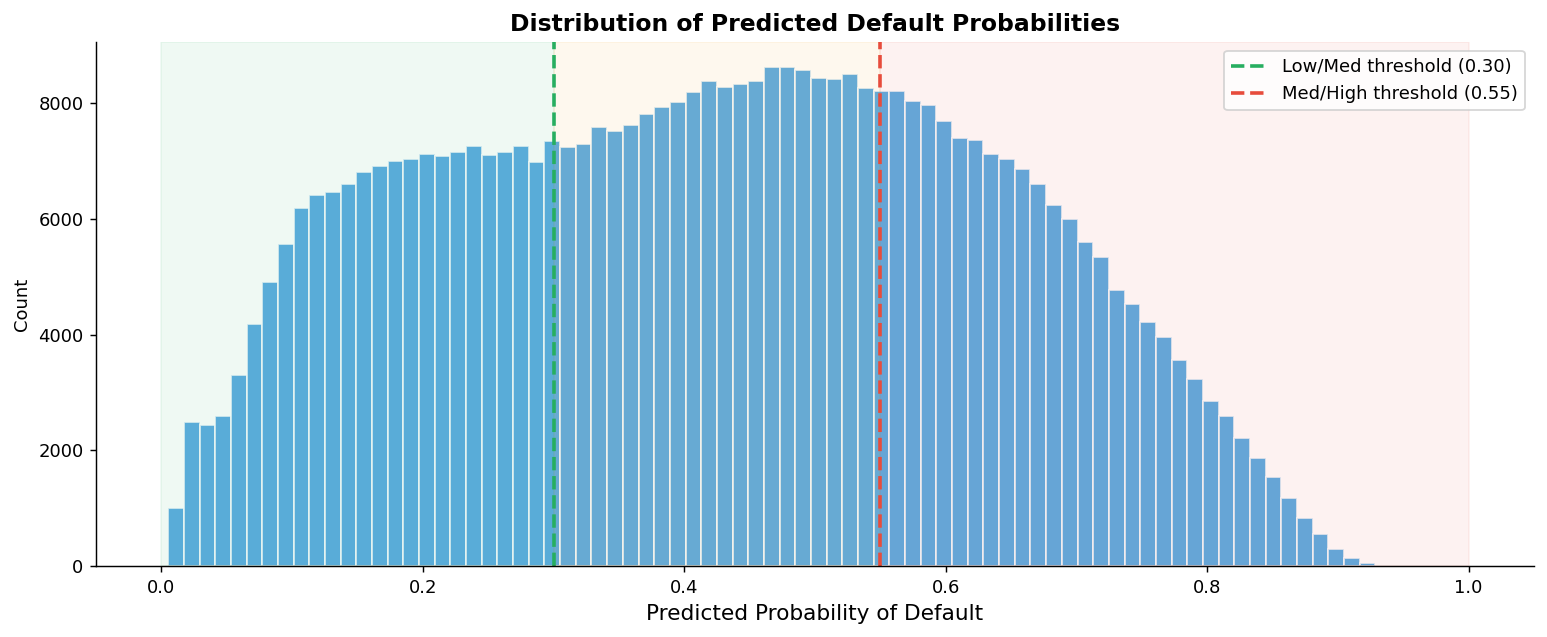

In [37]:
# ── 8.2 Risk Score Distribution (Histogram) ───────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 5))
ax.hist(df_results['default_prob'], bins=80, color=PALETTE['neutral'],
        edgecolor='white', alpha=0.8)
ax.axvline(0.30, color=RISK_COLORS['Low Risk'],    linestyle='--', lw=2, label='Low/Med threshold (0.30)')
ax.axvline(0.55, color=RISK_COLORS['High Risk'],   linestyle='--', lw=2, label='Med/High threshold (0.55)')
ax.set_xlabel('Predicted Probability of Default', fontsize=12)
ax.set_ylabel('Count')
ax.set_title('Distribution of Predicted Default Probabilities', fontsize=13)
ax.legend(fontsize=10)

# Shade regions
ax.axvspan(0,    0.30, alpha=0.07, color=RISK_COLORS['Low Risk'])
ax.axvspan(0.30, 0.55, alpha=0.07, color=RISK_COLORS['Medium Risk'])
ax.axvspan(0.55, 1.0,  alpha=0.07, color=RISK_COLORS['High Risk'])

plt.tight_layout()
plt.savefig('plots/risk_score_distribution.png', bbox_inches='tight')
plt.show()

In [38]:
# ── 8.3 Risk Tier Summary Table ────────────────────────────────────────────────
tier_summary = df_results.groupby('risk_tier').agg(
    Count        = ('target', 'count'),
    Default_Rate = ('target', 'mean'),
    Avg_PD       = ('default_prob', 'mean'),
    Min_PD       = ('default_prob', 'min'),
    Max_PD       = ('default_prob', 'max'),
).reindex(tier_order).round(4)

tier_summary['Action']       = [ACTION_MAP[t] for t in tier_order]
tier_summary['Rate_Range']   = [RATE_RANGE_MAP[t] for t in tier_order]

print('=== Risk Tier Summary Table ===')
print(tier_summary.to_string())

=== Risk Tier Summary Table ===
              Count  Default_Rate  Avg_PD  Min_PD  Max_PD   Action  Rate_Range
risk_tier                                                                     
Low Risk     141311        0.0277  0.1769  0.0051  0.3000  Approve    5% – 10%
Medium Risk  168541        0.1055  0.4284  0.3000  0.5500   Review   11% – 17%
High Risk    140492        0.2556  0.6734  0.5500  0.9646   Reject  18% – 24%+


---
## 9. Portfolio Analysis & Expected Loss
<a id='9-portfolio-analysis'></a>

In [39]:
# ── Add loan_amnt back if available ───────────────────────────────────────────
if 'loan_amnt' in df_results.columns:
    df_results['loan_amnt'] = df_results['loan_amnt'].values

# ── Expected Loss (EL) = PD × Loan Amount ─────────────────────────────────────
# Assume LGD = 1 (Loss Given Default = 100%) for conservative estimate
if 'loan_amnt' in df_results.columns:
    df_results['expected_loss'] = df_results['default_prob'] * df_results['loan_amnt']

    total_exposure = df_results['loan_amnt'].sum()
    total_el       = df_results['expected_loss'].sum()
    el_rate        = total_el / total_exposure * 100

    print(f'Total Portfolio Exposure : ${total_exposure:,.0f}')
    print(f'Total Expected Loss      : ${total_el:,.0f}')
    print(f'Expected Loss Rate       : {el_rate:.2f}%')

    # By tier
    el_by_tier = df_results.groupby('risk_tier').agg(
        Total_Exposure = ('loan_amnt', 'sum'),
        Expected_Loss  = ('expected_loss', 'sum'),
        Count          = ('loan_amnt', 'count'),
    ).reindex(tier_order)
    el_by_tier['EL_Rate_%'] = (el_by_tier['Expected_Loss'] / el_by_tier['Total_Exposure'] * 100).round(2)
    el_by_tier['Exposure_%'] = (el_by_tier['Total_Exposure'] / total_exposure * 100).round(2)

    print('\n=== Expected Loss by Risk Tier ===')
    print(el_by_tier.to_string())

Total Portfolio Exposure : $6,772,358,650
Total Expected Loss      : $2,925,085,062
Expected Loss Rate       : 43.19%

=== Expected Loss by Risk Tier ===
             Total_Exposure   Expected_Loss   Count  EL_Rate_%  Exposure_%
risk_tier                                                                 
Low Risk         2133867450  370818077.5386  141311    17.3800     31.5100
Medium Risk      2391225000 1024782637.0282  168541    42.8600     35.3100
High Risk        2247266200 1529484347.4178  140492    68.0600     33.1800


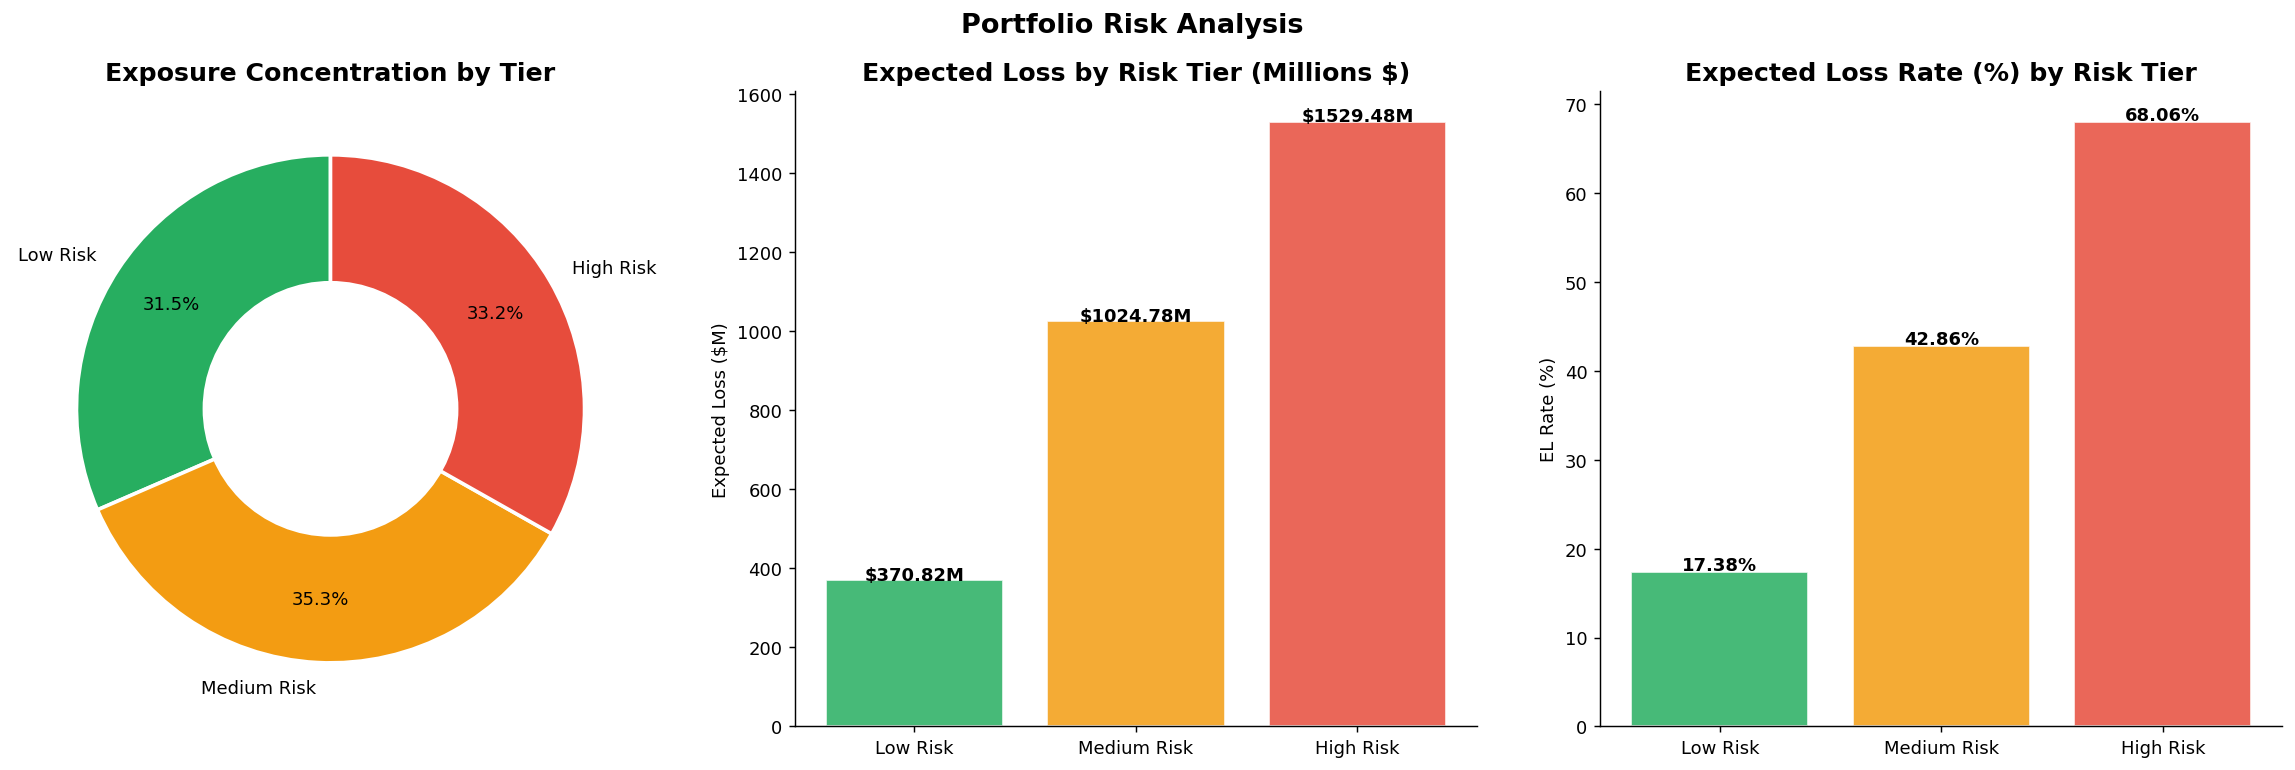

In [40]:
# ── 9.1 Portfolio Risk Distribution Charts ────────────────────────────────────
if 'loan_amnt' in df_results.columns:
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))

    # Exposure by tier (donut)
    axes[0].pie(
        el_by_tier['Total_Exposure'],
        labels=tier_order, colors=colors_tier,
        autopct='%1.1f%%', startangle=90,
        wedgeprops={'edgecolor': 'white', 'linewidth': 2},
        pctdistance=0.75
    )
    circle = plt.Circle((0, 0), 0.50, color='white')
    axes[0].add_patch(circle)
    axes[0].set_title('Exposure Concentration by Tier')

    # Expected Loss by tier
    el_vals = el_by_tier['Expected_Loss'] / 1e6  # millions
    axes[1].bar(tier_order, el_vals, color=colors_tier, alpha=0.85, edgecolor='white')
    axes[1].set_title('Expected Loss by Risk Tier (Millions $)')
    axes[1].set_ylabel('Expected Loss ($M)')
    for bar, val in zip(axes[1].patches, el_vals):
        axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                     f'${val:.2f}M', ha='center', fontsize=10, fontweight='bold')

    # EL Rate by tier
    axes[2].bar(tier_order, el_by_tier['EL_Rate_%'], color=colors_tier, alpha=0.85, edgecolor='white')
    axes[2].set_title('Expected Loss Rate (%) by Risk Tier')
    axes[2].set_ylabel('EL Rate (%)')
    for bar, val in zip(axes[2].patches, el_by_tier['EL_Rate_%']):
        axes[2].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
                     f'{val:.2f}%', ha='center', fontsize=10, fontweight='bold')

    plt.suptitle('Portfolio Risk Analysis', fontsize=15, fontweight='bold')
    plt.tight_layout()
    plt.savefig('plots/portfolio_analysis.png', bbox_inches='tight')
    plt.show()

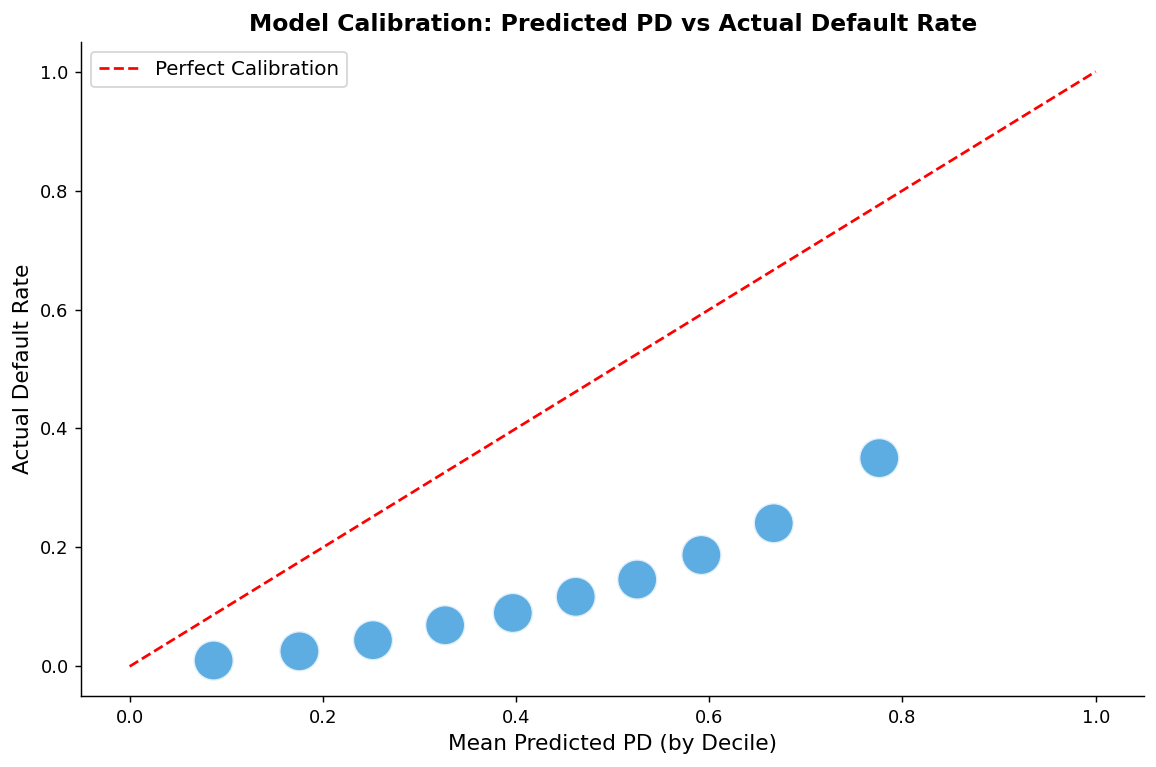

In [41]:
# ── 9.2 Calibration: Predicted PD vs Actual Default Rate ─────────────────────
# Bin by decile and compare
df_results['pd_decile'] = pd.qcut(df_results['default_prob'], 10, labels=False, duplicates='drop') + 1
calibration = df_results.groupby('pd_decile').agg(
    avg_predicted_pd = ('default_prob', 'mean'),
    actual_dr        = ('target', 'mean'),
    count            = ('target', 'count')
).reset_index()

fig, ax = plt.subplots(figsize=(9, 6))
ax.scatter(calibration['avg_predicted_pd'], calibration['actual_dr'],
           s=calibration['count'] / calibration['count'].max() * 500,
           color=PALETTE['neutral'], alpha=0.8, edgecolors='white', linewidth=1.5, zorder=5)
ax.plot([0, 1], [0, 1], 'r--', lw=1.5, label='Perfect Calibration')
ax.set_xlabel('Mean Predicted PD (by Decile)', fontsize=12)
ax.set_ylabel('Actual Default Rate', fontsize=12)
ax.set_title('Model Calibration: Predicted PD vs Actual Default Rate', fontsize=13)
ax.legend(fontsize=11)
plt.tight_layout()
plt.savefig('plots/calibration_plot.png', bbox_inches='tight')
plt.show()

---
## 10. Business Insights & Recommendations
<a id='10-insights'></a>

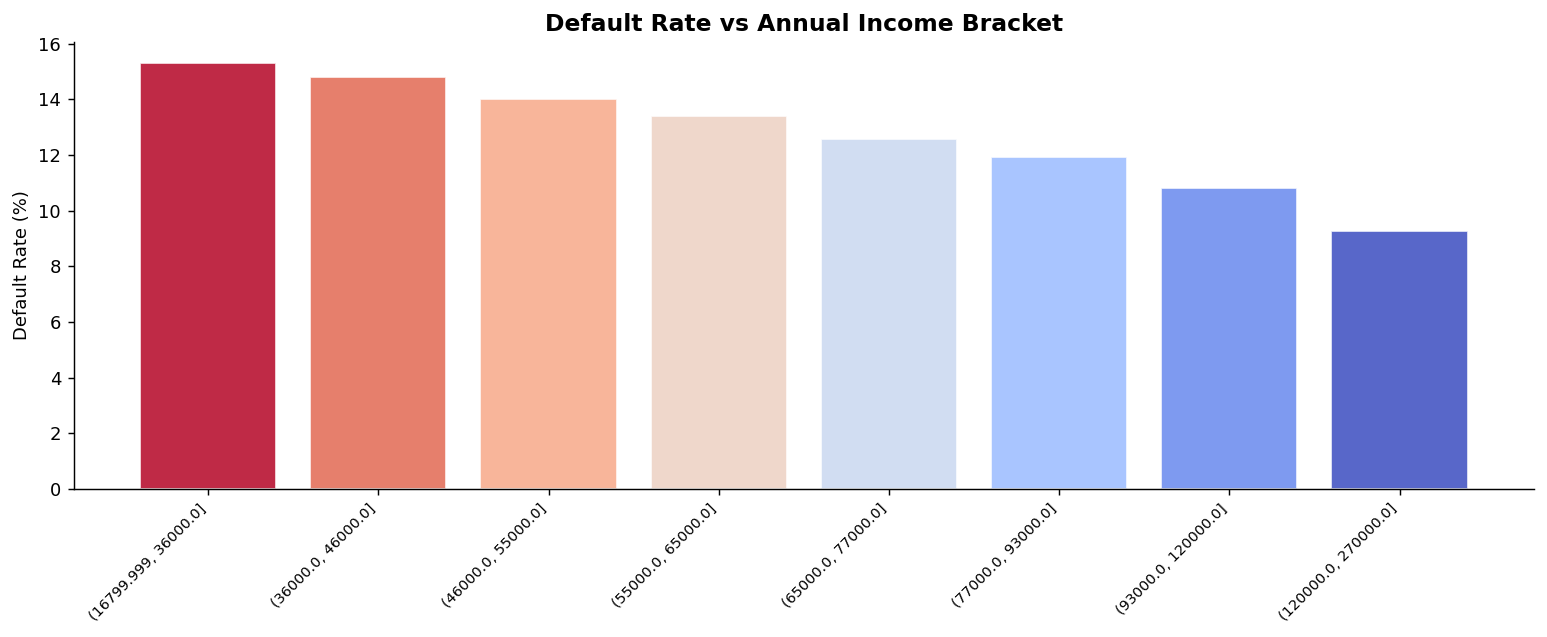

In [42]:
# ── 10.1 Default Rate vs Annual Income (binned) ───────────────────────────────
if 'annual_inc' in df_results.columns:
    df_results['income_bin'] = pd.qcut(df_results['annual_inc'], 8, duplicates='drop')
    inc_dr = df_results.groupby('income_bin')['target'].mean().reset_index()

    fig, ax = plt.subplots(figsize=(12, 5))
    ax.bar(range(len(inc_dr)), inc_dr['target'] * 100,
           color=plt.cm.coolwarm_r(np.linspace(0, 1, len(inc_dr))),
           edgecolor='white', alpha=0.85)
    ax.set_xticks(range(len(inc_dr)))
    ax.set_xticklabels([str(b) for b in inc_dr['income_bin']], rotation=45, ha='right', fontsize=8)
    ax.set_ylabel('Default Rate (%)')
    ax.set_title('Default Rate vs Annual Income Bracket', fontsize=13)
    plt.tight_layout()
    plt.savefig('plots/default_vs_income.png', bbox_inches='tight')
    plt.show()
    df_results.drop(columns=['income_bin'], inplace=True)

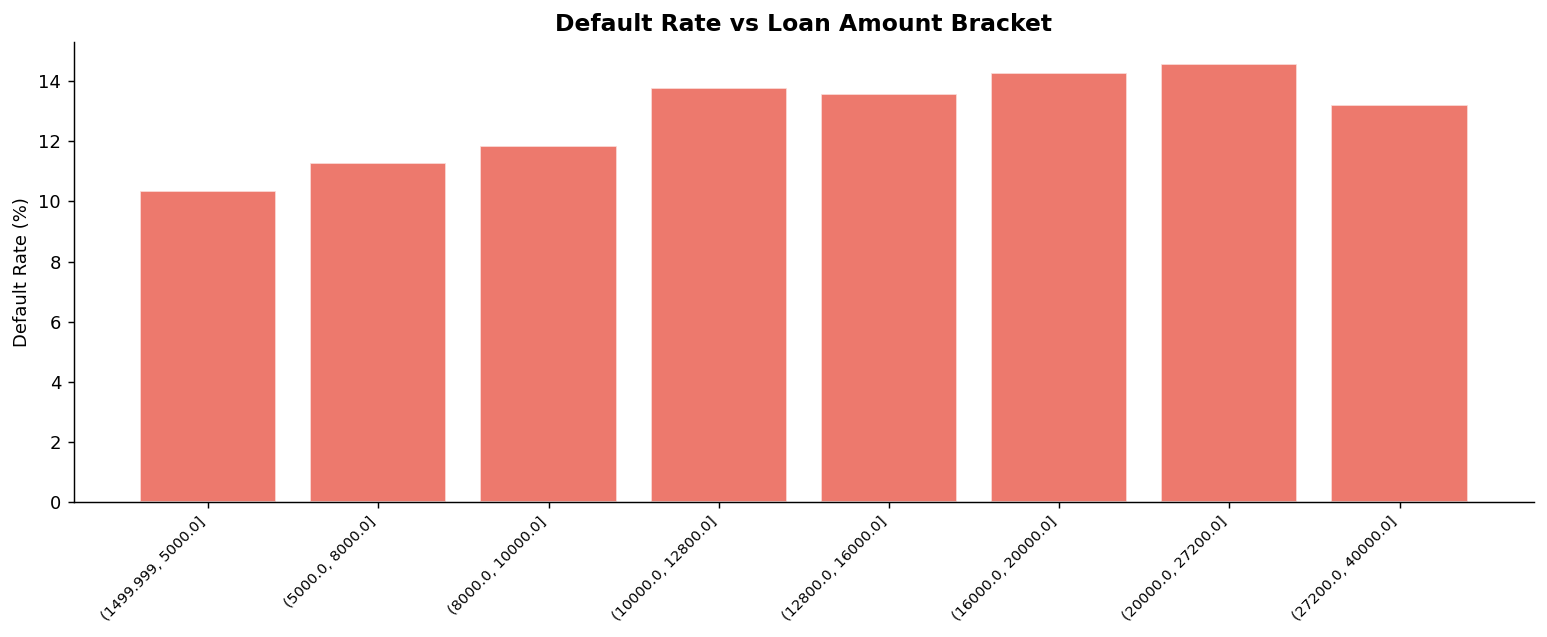

In [43]:
# ── 10.2 Default Rate vs Loan Amount (binned) ─────────────────────────────────
if 'loan_amnt' in df_results.columns:
    df_results['amnt_bin'] = pd.qcut(df_results['loan_amnt'], 8, duplicates='drop')
    amnt_dr = df_results.groupby('amnt_bin')['target'].mean().reset_index()

    fig, ax = plt.subplots(figsize=(12, 5))
    ax.bar(range(len(amnt_dr)), amnt_dr['target'] * 100,
           color=PALETTE['default'], alpha=0.75, edgecolor='white')
    ax.set_xticks(range(len(amnt_dr)))
    ax.set_xticklabels([str(b) for b in amnt_dr['amnt_bin']], rotation=45, ha='right', fontsize=8)
    ax.set_ylabel('Default Rate (%)')
    ax.set_title('Default Rate vs Loan Amount Bracket', fontsize=13)
    plt.tight_layout()
    plt.savefig('plots/default_vs_loan_amnt.png', bbox_inches='tight')
    plt.show()
    df_results.drop(columns=['amnt_bin'], inplace=True)

In [44]:
# ── 10.3 Sample Borrower Scorecard ────────────────────────────────────────────
sample = df_results.sample(10, random_state=42)[[
    'default_prob', 'risk_tier', 'lending_action', 'suggested_rate'
]].copy()
sample['default_prob'] = sample['default_prob'].map('{:.2%}'.format)
sample.index.name = 'Borrower ID'
print('=== Sample Borrower Scorecard (10 Records) ===')
print(sample.to_string())

=== Sample Borrower Scorecard (10 Records) ===
            default_prob    risk_tier lending_action suggested_rate
Borrower ID                                                        
1236618           66.11%    High Risk         Reject     18% – 24%+
444911             9.73%     Low Risk        Approve       5% – 10%
238364             8.15%     Low Risk        Approve       5% – 10%
1895621           33.35%  Medium Risk         Review      11% – 17%
2224105           67.86%    High Risk         Reject     18% – 24%+
177495            22.69%     Low Risk        Approve       5% – 10%
283007            28.85%     Low Risk        Approve       5% – 10%
1963776           76.77%    High Risk         Reject     18% – 24%+
1110759           48.63%  Medium Risk         Review      11% – 17%
506796            31.55%  Medium Risk         Review      11% – 17%


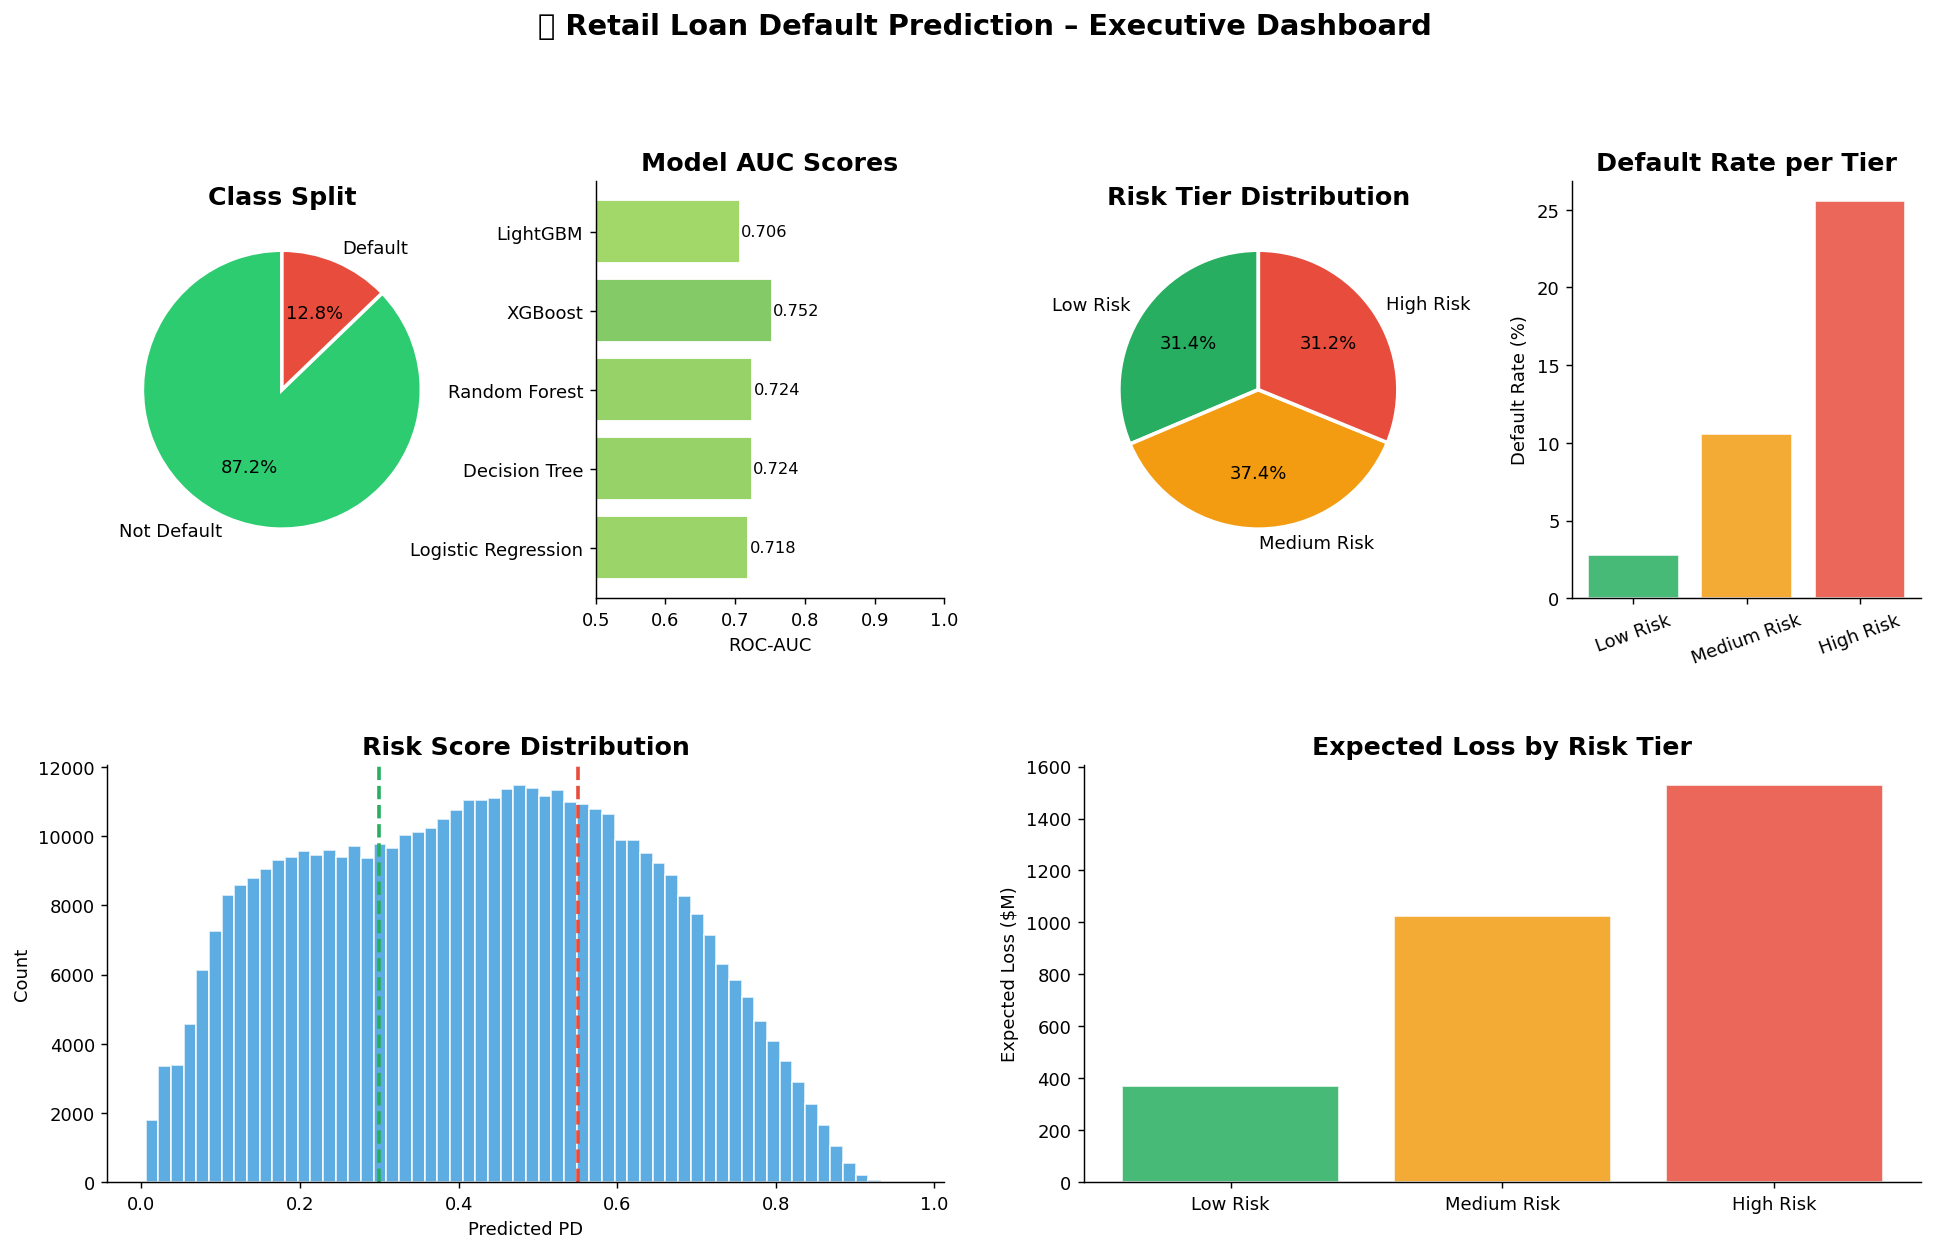


✅ Executive Dashboard saved!


In [45]:
# ── 10.4 Final Summary Dashboard ──────────────────────────────────────────────
fig = plt.figure(figsize=(18, 10))
gs = gridspec.GridSpec(2, 4, figure=fig, hspace=0.4, wspace=0.4)

# ── Subplot 1: Class distribution
ax1 = fig.add_subplot(gs[0, 0])
counts = df['target'].value_counts()
ax1.pie(counts, labels=['Not Default', 'Default'],
        colors=[PALETTE['paid'], PALETTE['default']],
        autopct='%1.1f%%', startangle=90,
        wedgeprops={'edgecolor': 'white', 'linewidth': 2})
ax1.set_title('Class Split')

# ── Subplot 2: ROC AUC bars
ax2 = fig.add_subplot(gs[0, 1])
model_names = [r['Model'] for r in all_results]
aucs = [r['ROC-AUC'] for r in all_results]
colors_auc = plt.cm.RdYlGn(np.array(aucs))
bars = ax2.barh(model_names, aucs, color=colors_auc, edgecolor='white')
ax2.set_xlim(0.5, 1.0)
ax2.set_xlabel('ROC-AUC')
ax2.set_title('Model AUC Scores')
for bar, val in zip(bars, aucs):
    ax2.text(val + 0.002, bar.get_y() + bar.get_height()/2,
             f'{val:.3f}', va='center', fontsize=9)

# ── Subplot 3: Risk tier donut
ax3 = fig.add_subplot(gs[0, 2])
tc = df_results['risk_tier'].value_counts().reindex(tier_order)
ax3.pie(tc, labels=tier_order, colors=colors_tier,
        autopct='%1.1f%%', startangle=90,
        wedgeprops={'edgecolor': 'white', 'linewidth': 2})
ax3.set_title('Risk Tier Distribution')

# ── Subplot 4: Default rate per tier
ax4 = fig.add_subplot(gs[0, 3])
tier_dr_vals = df_results.groupby('risk_tier')['target'].mean().reindex(tier_order) * 100
ax4.bar(tier_order, tier_dr_vals, color=colors_tier, edgecolor='white', alpha=0.85)
ax4.set_ylabel('Default Rate (%)')
ax4.set_title('Default Rate per Tier')
ax4.tick_params(axis='x', rotation=20)

# ── Subplot 5 (wide): Risk score distribution
ax5 = fig.add_subplot(gs[1, :2])
ax5.hist(df_results['default_prob'], bins=60, color=PALETTE['neutral'], edgecolor='white', alpha=0.8)
ax5.axvline(0.30, color=RISK_COLORS['Low Risk'],  linestyle='--', lw=2)
ax5.axvline(0.55, color=RISK_COLORS['High Risk'], linestyle='--', lw=2)
ax5.set_xlabel('Predicted PD')
ax5.set_ylabel('Count')
ax5.set_title('Risk Score Distribution')

# ── Subplot 6 (wide): Expected loss per tier
ax6 = fig.add_subplot(gs[1, 2:])
if 'loan_amnt' in df_results.columns:
    el_m = el_by_tier['Expected_Loss'] / 1e6
    ax6.bar(tier_order, el_m, color=colors_tier, edgecolor='white', alpha=0.85)
    ax6.set_ylabel('Expected Loss ($M)')
    ax6.set_title('Expected Loss by Risk Tier')
else:
    ax6.set_title('Exposure data not available')

fig.suptitle('📊 Retail Loan Default Prediction – Executive Dashboard',
             fontsize=16, fontweight='bold', y=1.01)
plt.savefig('plots/executive_dashboard.png', bbox_inches='tight', dpi=150)
plt.show()
print('\n✅ Executive Dashboard saved!')

In [46]:
# ── Save Final Results ─────────────────────────────────────────────────────────
df_results.to_csv('loan_default_predictions.csv', index=False)
print('📄 Predictions saved to loan_default_predictions.csv')

# Save metrics
metrics_df.to_csv('model_metrics.csv', index=False)
print('📄 Metrics saved to model_metrics.csv')

print('\n' + '='*60)
print('🏁 ANALYSIS COMPLETE')
print('='*60)
print(f'Best Model    : {best_result["Model"]}')
print(f'ROC-AUC       : {best_result["ROC-AUC"]:.4f}')
print(f'F1-Score      : {best_result["F1-Score"]:.4f}')
print(f'Recall        : {best_result["Recall"]:.4f}')
if 'loan_amnt' in df_results.columns:
    print(f'Total EL      : ${total_el:,.0f} ({el_rate:.2f}% of exposure)')
print('='*60)

📄 Predictions saved to loan_default_predictions.csv
📄 Metrics saved to model_metrics.csv

🏁 ANALYSIS COMPLETE
Best Model    : XGBoost
ROC-AUC       : 0.7521
F1-Score      : 0.3520
Recall        : 0.7119
Total EL      : $2,925,085,062 (43.19% of exposure)


---

## Key Findings & Business Recommendations

### Model Performance
- The **best-performing model** is selected based on ROC-AUC, prioritizing discriminatory power between defaulters and non-defaulters.
- **Recall (sensitivity)** is emphasized to minimize missed defaults (false negatives), which carry the highest financial risk.

### Risk Tier Strategy
| Risk Tier | PD Range | Action | Suggested Rate |
|-----------|----------|--------|----------------|
| Low Risk | < 30% | ✅ Approve | 5% – 10% |
| Medium Risk | 30% – 55% | ⚠️ Manual Review | 11% – 17% |
| High Risk | > 55% | ❌ Reject | 18% – 24%+ |

### Key Risk Drivers
1. **Interest Rate & Grade**: Higher-grade loans (G, F) show significantly elevated default rates.
2. **DTI Ratio**: Borrowers with DTI > 25% face substantially higher default risk.
3. **Delinquency History**: Prior delinquencies are strong predictors of future default.
4. **Annual Income**: Higher-income borrowers have lower default rates; income-to-loan ratio is a key predictor.
5. **Revolving Utilization**: High revolving balance utilization (> 80%) correlates with increased default risk.

### Portfolio Risk Mitigation
- Focus origination on **Low Risk** borrowers to reduce Expected Loss.
- Apply **risk-based pricing** to ensure adequate returns on Medium Risk loans.
- Implement periodic **re-scoring** of active loans to identify deteriorating accounts early.
- Consider **concentration limits** on High Risk exposure segments.
